# Comparing Metropolis and Event-Chain Monte Carlo

This notebook compares Metropolis Monte Carlo and Event-Chain Monte Carlo (ECMC) for single-well and double-well potentials. The algorithms are compared using their empirical cumulative distribution functions, trajectories and autocorrelation.

## Imports and General Functions

This section imports the required libraries and defines functions used throughout the notebook.

In [1]:
# import all necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# set random seed for reproducibility
rng = np.random.default_rng(seed=42)

## Single-Well Potential

The first comparison uses the single-well potential

$$
U(x)=x^2.
$$

The corresponding target distribution at temperature $T$ is proportional to

$$
\pi_T(x)\propto \exp\left(-\frac{U(x)}{T}\right).
$$

In [2]:
def U_single(x):
    """
    Calculate the potential energy for a single particle.

    Args:
        x (float): Position of the particle.

    Returns:
        float: Potential energy of the particle.
    """
    return x**2

def dU_single(x):
    """
    Calculate the derivative of the potential energy for a single particle.

    Args:
        x (float): Position of the particle.

    Returns:
        float: Derivative of the potential energy.
    """
    return 2 * x

def target_distribution(x_grid, potential_func, temperature):
    
    weights = np.exp(-potential_func(x_grid) / temperature)
    normalise = np.trapezoid(weights, x_grid)
    return weights / normalise 

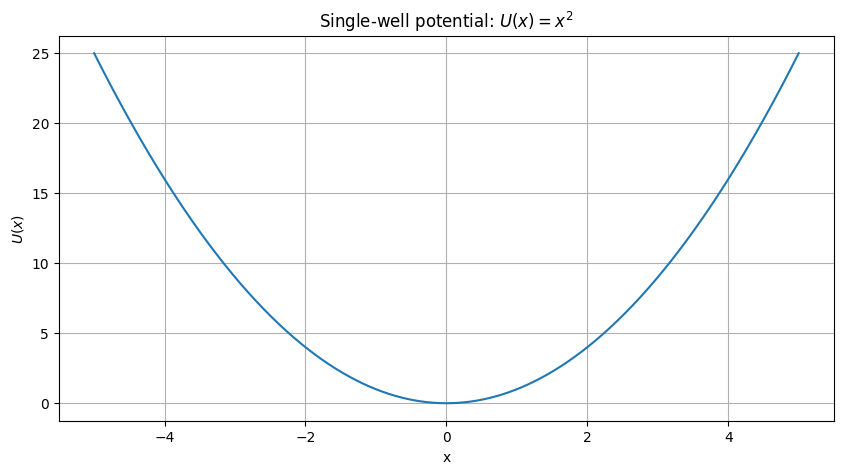

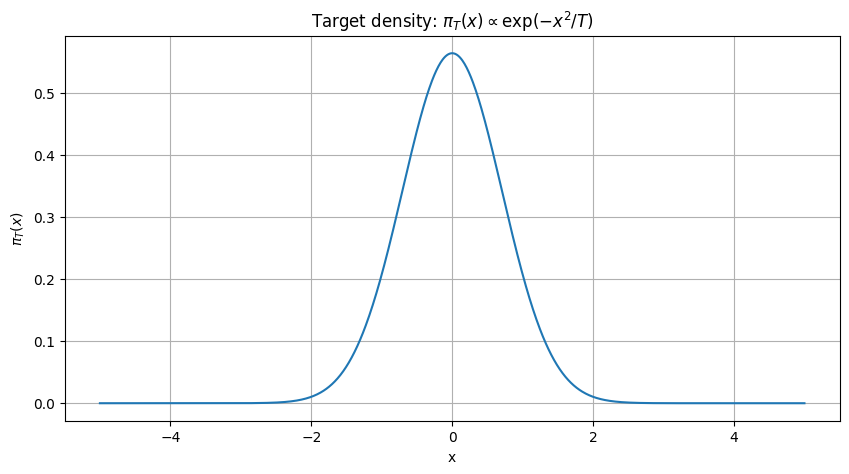

In [3]:
temperature = 1.0

x_grid = np.linspace(-5, 5, 1000)
density = target_distribution(x_grid, U_single, temperature)

plt.figure(figsize=(10, 5))
plt.plot(x_grid, U_single(x_grid))
plt.xlabel("x")
plt.ylabel(r"$U(x)$")
plt.title(r"Single-well potential: $U(x)=x^2$")
plt.grid()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(x_grid, density)
plt.xlabel("x")
plt.ylabel(r"$\pi_T(x)$")
plt.title(r"Target density: $\pi_T(x) \propto \exp(-x^2/T)$")
plt.grid()
plt.show()

### Metropolis Sampling

The Metropolis algorithm generates samples using random proposals that are accepted or rejected according to the change in potential energy.

In [4]:
def metropolis_step(x_current, proposal_width, temperature, potential_func, rng):
    
    noise = rng.uniform(-proposal_width / 2, proposal_width / 2)
    x_proposed = x_current + noise
    
    delta_U = potential_func(x_proposed) - potential_func(x_current)
    
    acceptance_prob = min(1, np.exp(-delta_U / temperature))
    
    if rng.random() < acceptance_prob:
        return x_proposed, True
    else:
        return x_current, False
    
def run_metropolis(initial_x, num_steps, proposal_width, temperature, potential_func, rng):
    
    trajectory = np.empty(num_steps + 1)
    trajectory[0] = initial_x
    
    current_x = initial_x
    accepted_moves = 0
    
    for step in range(1, num_steps + 1):
        current_x, accepted = metropolis_step(current_x, proposal_width, temperature, potential_func, rng)
        trajectory[step] = current_x
        
        if accepted:
            accepted_moves += 1
            
    acceptance_rate = accepted_moves / num_steps
    
    return trajectory, acceptance_rate

In [5]:
temperature = 1.0
initial_x = 5.0
num_steps = 10**5
proposal_width = 2.0
burn_in = 1_000

metropolis_trajectory, metropolis_acceptance_rate = run_metropolis(
    initial_x=initial_x,
    num_steps=num_steps,
    proposal_width=proposal_width,
    temperature=temperature,
    potential_func=U_single,
    rng=rng
)

print(f"Metropolis acceptance rate: {metropolis_acceptance_rate:.2%}")

Metropolis acceptance rate: 72.88%


### Cumulative Distribution Functions

The empirical CDF of the generated samples is compared with the theoretical CDF of the target distribution.

In [6]:
def empirical_cdf(samples):
    """
    Calculate the empirical cumulative density function (CDF) from the given samples.

    Args:
        samples (array-like): A list or array of samples.

    Returns:
        tuple: A tuple containing the sorted samples and their corresponding cumulative probabilities.
    """
    sorted_samples = np.sort(samples)
    cumulative_probs = np.arange(1, len(sorted_samples) + 1) / len(sorted_samples)
    return sorted_samples, cumulative_probs

def theoretical_cdf(x_grid, potential_func, temperature):
    """
    Calculate the theoretical cumulative density function (CDF) based on the target distribution.

    Args:
        x_grid (float): The grid of x values over which to compute the CDF.
        potential_func (float): The potential energy function.
        temperature (float): The temperature parameter for the target distribution.

    Returns:
        array: Theoretical cumulative probabilities corresponding to the x_grid.
    """ 
    density = target_distribution(x_grid, potential_func, temperature)

    cumulative = np.zeros_like(x_grid)
    cumulative[1:] = np.cumsum(
        0.5 * (density[1:] + density[:-1]) * np.diff(x_grid)
    )

    cumulative = cumulative / cumulative[-1]

    return cumulative

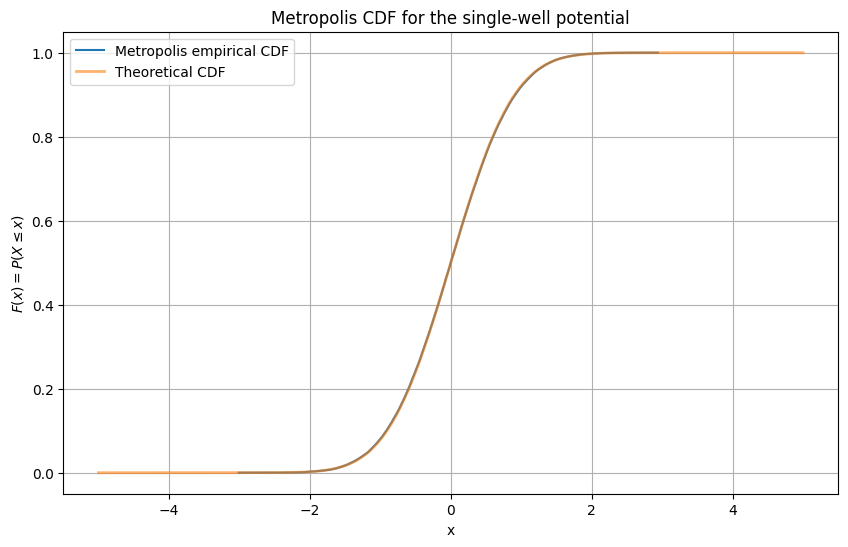

In [7]:
metropolis_samples = metropolis_trajectory[burn_in:]

metropolis_x_cdf, metropolis_y_cdf = empirical_cdf(metropolis_samples)

x_grid = np.linspace(-5, 5, 4000)
theory_cdf = theoretical_cdf(x_grid, U_single, temperature)

plt.figure(figsize=(10, 6))

plt.plot(
    metropolis_x_cdf,
    metropolis_y_cdf,
    label="Metropolis empirical CDF"
)

plt.plot(
    x_grid,
    theory_cdf,
    linewidth=2,
    alpha=0.6,
    label="Theoretical CDF"
)

plt.xlabel("x")
plt.ylabel(r"$F(x) = P(X \leq x)$")
plt.title("Metropolis CDF for the single-well potential")
plt.grid()
plt.legend()
plt.show()

### Event-Chain Monte Carlo

Apply ECMC to the single-well potential by calculating the distance to the next event.

In [8]:
def distance_to_next_event_single_well(x_current, velocity, temperature, rng):
    """
    Calculate the distance to the next event in a single-well potential.

    Args:
        x_current (float): The current position.
        velocity (float): The velocity.
        temperature (float): The temperature.
        rng (numpy.random.Generator): A random number generator.

    Returns:
        float: The distance to the next event.
    """
    
    uphill_energy = rng.exponential(scale=temperature)
    
    y0 = velocity * x_current
    
    if y0 < 0:
        distance_to_minimum = -y0
        
        uphill_distance = np.sqrt(uphill_energy)
        
        return distance_to_minimum + uphill_distance
    
    else:
        return np.sqrt(y0**2 + uphill_energy) - y0

In [9]:
def run_ecmc_single_well(initial_x, num_burn_in_steps, num_samples, distance_between_samples, temperature, potential_func, rng):
    """
    Run the Event-Chain Monte Carlo (ECMC) algorithm for a single-well potential.
    
    Args:
        initial_x (float): The initial position of the particle.
        num_burn_in_steps (int): The number of burn-in steps before sampling.
        num_samples (int): The number of samples to collect after burn-in.
        distance_between_samples (float): The distance to move between samples.
        temperature (float): The temperature parameter for the target distribution.
        potential_func (callable): The potential energy function.
        rng (numpy.random.Generator): A random number generator.
        
    Returns:
        np.ndarray: An array containing the potential trajectory and position trajectory.
    """
        
    current_x = initial_x

    num_iterations = num_burn_in_steps + num_samples

    potential_trajectory = np.empty(num_iterations)
    position_trajectory = np.empty(num_iterations)

    num_events = 0

    for iteration in range(num_iterations):

        # Uniformly resample the velocity at the start of each sampling interval.
        velocity = rng.choice([-1, 1])

        distance_remaining = distance_between_samples

        while distance_remaining > 0:

            distance_to_event = distance_to_next_event_single_well(
                current_x,
                velocity,
                temperature,
                rng
            )

            if distance_to_event <= distance_remaining:
                # Move to the event.
                current_x += velocity * distance_to_event

                # Reduce the remaining distance.
                distance_remaining -= distance_to_event

                # Bounce at the event.
                velocity *= -1

                num_events += 1

            else:
                # No event before the next sample.
                current_x += velocity * distance_remaining
                distance_remaining = 0

        potential_trajectory[iteration] = potential_func(current_x)
        position_trajectory[iteration] = current_x

    print(f"Number of ECMC events: {num_events}")

    return np.array([potential_trajectory, position_trajectory])

Number of ECMC events: 57022


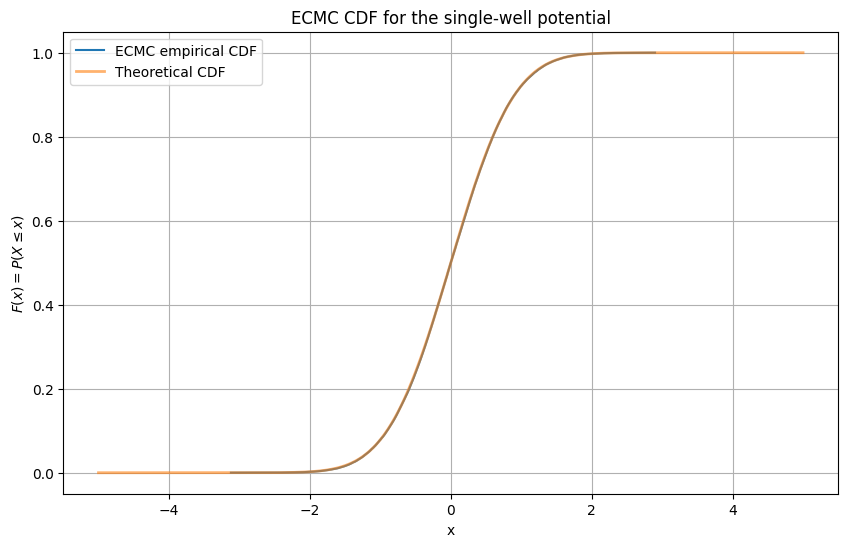

In [10]:
num_burn_in_steps = 1_000
num_samples = 10**5
distance_between_samples = 1.0
initial_x = 5.0
temperature = 1.0

ecmc_trajectory = run_ecmc_single_well(
    initial_x=initial_x,
    temperature=temperature,
    num_burn_in_steps=num_burn_in_steps,
    num_samples=num_samples,
    distance_between_samples=distance_between_samples,
    potential_func=U_single,
    rng=rng
)

ecmc_potential_samples = ecmc_trajectory[0, num_burn_in_steps:]
ecmc_position_samples = ecmc_trajectory[1, num_burn_in_steps:]

ecmc_x_cdf, ecmc_y_cdf = empirical_cdf(ecmc_position_samples)

x_grid = np.linspace(-5, 5, 4000)
theory_cdf = theoretical_cdf(x_grid, U_single, temperature)

plt.figure(figsize=(10, 6))

plt.plot(
    ecmc_x_cdf,
    ecmc_y_cdf,
    label="ECMC empirical CDF"
)

plt.plot(
    x_grid,
    theory_cdf,
    linewidth=2,
    alpha=0.6,
    label="Theoretical CDF"
)

plt.xlabel("x")
plt.ylabel(r"$F(x) = P(X \leq x)$")
plt.title("ECMC CDF for the single-well potential")
plt.grid()
plt.legend()
plt.show()

### Single-Well Comparison

Compare the Metropolis and ECMC results for the single-well potential.

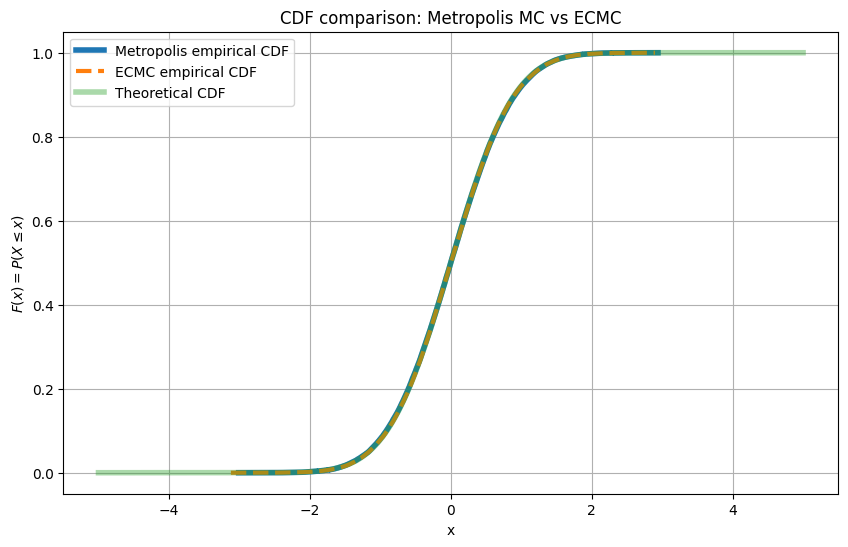

In [11]:
plt.figure(figsize=(10, 6))

plt.plot(
    metropolis_x_cdf,
    metropolis_y_cdf,
    linewidth=4,
    label="Metropolis empirical CDF"
)

plt.plot(
    ecmc_x_cdf,
    ecmc_y_cdf,
    linewidth=3,
    linestyle="--",
    label="ECMC empirical CDF"
)

plt.plot(
    x_grid,
    theory_cdf,
    linewidth=4,
    alpha=0.4,
    label="Theoretical CDF"
)

plt.xlabel("x")
plt.ylabel(r"$F(x) = P(X \leq x)$")
plt.title("CDF comparison: Metropolis MC vs ECMC")
plt.grid()
plt.legend()
plt.show()

### Autocorrelation Analysis

Calculate the autocorrelation and integrated autocorrelation time of the samples.

In [12]:
def normalised_autocorrelation(samples, max_lag):
    """
    Calculate the normalised autocorrelation of a set of samples up to a specified maximum lag.

    Args:
        samples (array-like): The set of samples for which to calculate the autocorrelation.
        max_lag (int): The maximum lag for which to calculate the autocorrelation.

    Returns:
        numpy.ndarray: The normalised autocorrelation values up to the specified maximum lag.
    """
    samples = np.asarray(samples)
    samples = samples - np.mean(samples)

    autocorr_full = np.correlate(samples, samples, mode="full")
    autocorr = autocorr_full[autocorr_full.size // 2:]

    autocorr = autocorr[:max_lag + 1]

    return autocorr / autocorr[0]

def estimate_iact(autocorr, cutoff=np.exp(-2)):
    """
    Estimate the integrated autocorrelation time.

    Args:
        autocorr (numpy.ndarray): The autocorrelation values.
        cutoff (float, optional): The threshold for determining the integrated autocorrelation time. Defaults to np.exp(-2).

    Returns:
        float: The estimated integrated autocorrelation time.
    """
    below = np.where(autocorr < cutoff)[0]

    if len(below) == 0:
        m = len(autocorr)
    else:
        m = max(1, below[0])

    tau_int = 2.0 * np.sum(autocorr[:m]) - 1.0

    return tau_int

def first_crossing_lag(autocorr, cutoff=np.exp(-2)):
    """
    Determine the first crossing lag where the autocorrelation falls below a specified cutoff.

    Args:
        autocorr (numpy.ndarray): The autocorrelation values.
        cutoff (float, optional): The threshold for determining the first crossing lag. Defaults to np.exp(-2).

    Returns:
        int: The first crossing lag.
    """
    below = np.where(autocorr < cutoff)[0]

    if len(below) == 0:
        return len(autocorr) - 1

    return int(below[0])

In [13]:
metropolis_position_samples = metropolis_samples
ecmc_position_samples = ecmc_trajectory[1, num_burn_in_steps:]

max_lag = 50

rho_metropolis = normalised_autocorrelation(
    metropolis_position_samples,
    max_lag
)

rho_ecmc = normalised_autocorrelation(
    ecmc_position_samples,
    max_lag
)

tau_metropolis = estimate_iact(rho_metropolis)
tau_ecmc = estimate_iact(rho_ecmc)

wait_metropolis = int(np.ceil(tau_metropolis))
wait_ecmc = int(np.ceil(tau_ecmc))

lag_metropolis = first_crossing_lag(rho_metropolis)
lag_ecmc = first_crossing_lag(rho_ecmc)

print(f"Metropolis: IACT ~ {tau_metropolis:.3f}, wait ~ {wait_metropolis} steps, first e^-2 crossing lag = {lag_metropolis}")
print(f"ECMC: IACT ~ {tau_ecmc:.3f}, wait ~ {wait_ecmc} steps, first e^-2 crossing lag = {lag_ecmc}")
print(f"Efficiency ratio (Metropolis / ECMC, by IACT) ~ {tau_metropolis / tau_ecmc:.2f}x")

Metropolis: IACT ~ 8.206, wait ~ 9 steps, first e^-2 crossing lag = 10
ECMC: IACT ~ 2.079, wait ~ 3 steps, first e^-2 crossing lag = 3
Efficiency ratio (Metropolis / ECMC, by IACT) ~ 3.95x


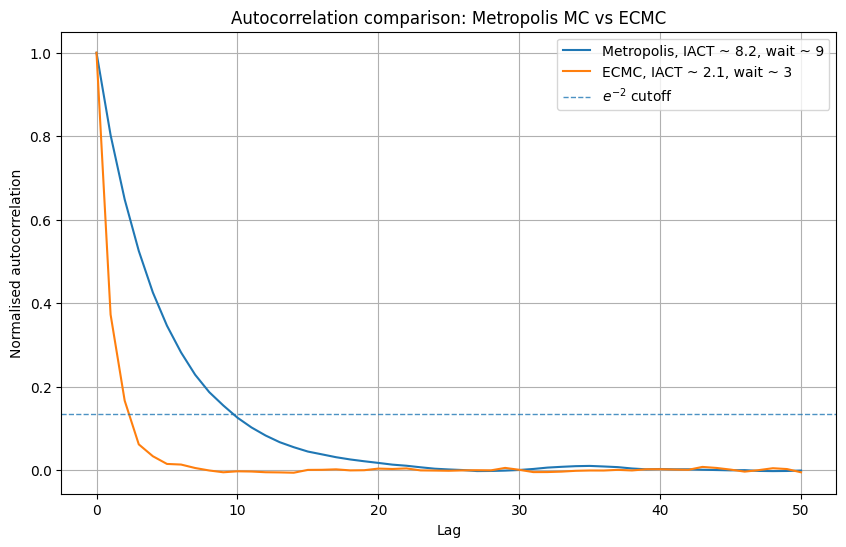

In [14]:
lags = np.arange(max_lag + 1)

plt.figure(figsize=(10, 6))

plt.plot(
    lags,
    rho_metropolis,
    label=f"Metropolis, IACT ~ {tau_metropolis:.1f}, wait ~ {wait_metropolis}"
)

plt.plot(
    lags,
    rho_ecmc,
    label=f"ECMC, IACT ~ {tau_ecmc:.1f}, wait ~ {wait_ecmc}"
)

plt.axhline(
    np.exp(-2),
    linestyle="--",
    linewidth=1,
    alpha=0.8,
    label=r"$e^{-2}$ cutoff"
)

plt.xlabel("Lag")
plt.ylabel("Normalised autocorrelation")
plt.title("Autocorrelation comparison: Metropolis MC vs ECMC")
plt.grid()
plt.legend()
plt.show()

## Double-Well Potential

The second comparison uses the double-well potential

$$
U(x)=-\frac{a}{2}x^2+\frac{b}{4}x^4.
$$

In [15]:
def U_double(x, a=2.0, b=1.0):
    """
    Calculate the double-well potential energy function.

    Args:
        x (float): The position at which to evaluate the potential.
        a (float, optional): The coefficient for the quadratic term. Defaults to 2.0.
        b (float, optional): The coefficient for the quartic term. Defaults to 1.0.

    Returns:
        float: The potential energy at position x.
    """
    return -(a / 2) * x**2 + (b / 4) * x**4

def dU_double(x, a=2.0, b=1.0):
    """
    Calculate the derivative of the double-well potential energy function.

    Args:
        x (float): The position at which to evaluate the derivative.
        a (float, optional): The coefficient for the quadratic term. Defaults to 2.0.
        b (float, optional): The coefficient for the quartic term. Defaults to 1.0.

    Returns:
        float: The derivative of the potential energy at position x.
    """
    return -a*x + b*x**3

In [16]:
a = 2.0
b = 1.0
temperature = 1.0

left_minimum = -np.sqrt(a / b)
right_minimum = np.sqrt(a / b)

barrier_position = 0.0

left_well_depth = U_double(left_minimum, a, b)
right_well_depth = U_double(right_minimum, a, b)
barrier_height = U_double(barrier_position, a, b)

barrier_from_well = barrier_height - left_well_depth

print(f"Left minimum: x = {left_minimum:.3f}")
print(f"Right minimum: x = {right_minimum:.3f}")
print(f"Barrier position: x = {barrier_position:.3f}")
print(f"Potential at each minimum: U = {left_well_depth:.3f}")
print(f"Barrier height: U = {barrier_height:.3f}")
print(f"Energy barrier from well to centre: barrier difference = {barrier_from_well:.3f}")

Left minimum: x = -1.414
Right minimum: x = 1.414
Barrier position: x = 0.000
Potential at each minimum: U = -1.000
Barrier height: U = 0.000
Energy barrier from well to centre: barrier difference = 1.000


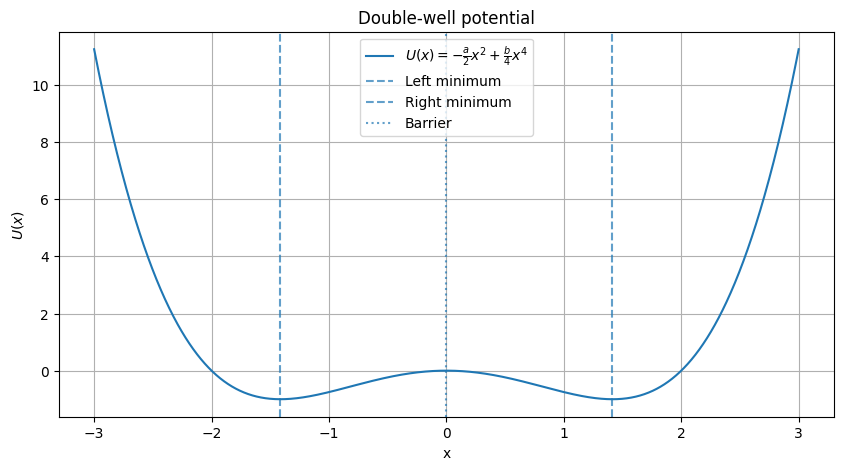

In [17]:
x_grid_double = np.linspace(-3, 3, 2000)

plt.figure(figsize=(10, 5))

plt.plot(
    x_grid_double,
    U_double(x_grid_double, a, b),
    label=r"$U(x) = -\frac{a}{2}x^2 + \frac{b}{4}x^4$"
)

plt.axvline(left_minimum, linestyle="--", alpha=0.7, label="Left minimum")
plt.axvline(right_minimum, linestyle="--", alpha=0.7, label="Right minimum")
plt.axvline(barrier_position, linestyle=":", alpha=0.7, label="Barrier")

plt.xlabel("x")
plt.ylabel(r"$U(x)$")
plt.title("Double-well potential")
plt.grid()
plt.legend()
plt.show()

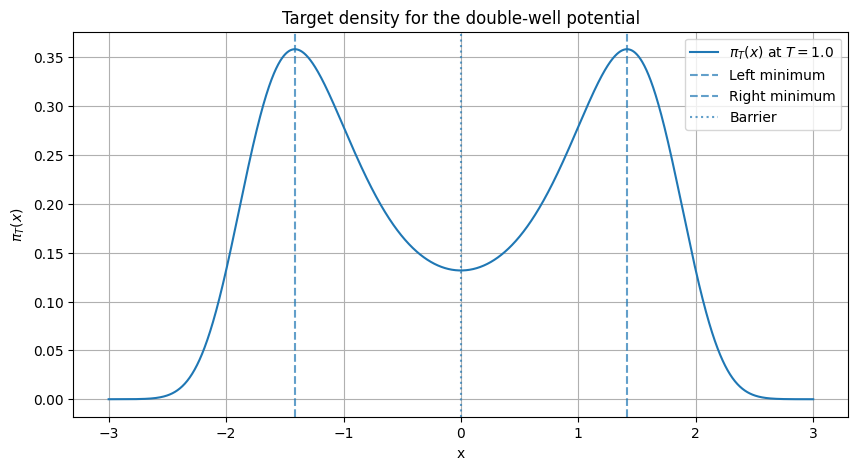

In [18]:
double_density = target_distribution(
    x_grid_double,
    lambda x: U_double(x, a, b),
    temperature
)

plt.figure(figsize=(10, 5))

plt.plot(
    x_grid_double,
    double_density,
    label=fr"$\pi_T(x)$ at $T={temperature}$"
)

plt.axvline(left_minimum, linestyle="--", alpha=0.7, label="Left minimum")
plt.axvline(right_minimum, linestyle="--", alpha=0.7, label="Right minimum")
plt.axvline(barrier_position, linestyle=":", alpha=0.7, label="Barrier")

plt.xlabel("x")
plt.ylabel(r"$\pi_T(x)$")
plt.title("Target density for the double-well potential")
plt.grid()
plt.legend()
plt.show()

### Double-Well Metropolis Sampling

Apply the Metropolis algorithm to the double-well potential.

In [19]:
double_potential = lambda x: U_double(x, a, b)

temperature = 1.0
initial_x = 0.0
num_steps = 10**5
proposal_width = 1.0
burn_in = 1_000

metropolis_double_trajectory, metropolis_double_acceptance_rate = run_metropolis(
    initial_x=initial_x,
    num_steps=num_steps,
    proposal_width=proposal_width,
    temperature=temperature,
    potential_func=double_potential,
    rng=rng
)

print(f"Double-well Metropolis acceptance rate: {metropolis_double_acceptance_rate:.2%}")

Double-well Metropolis acceptance rate: 85.96%


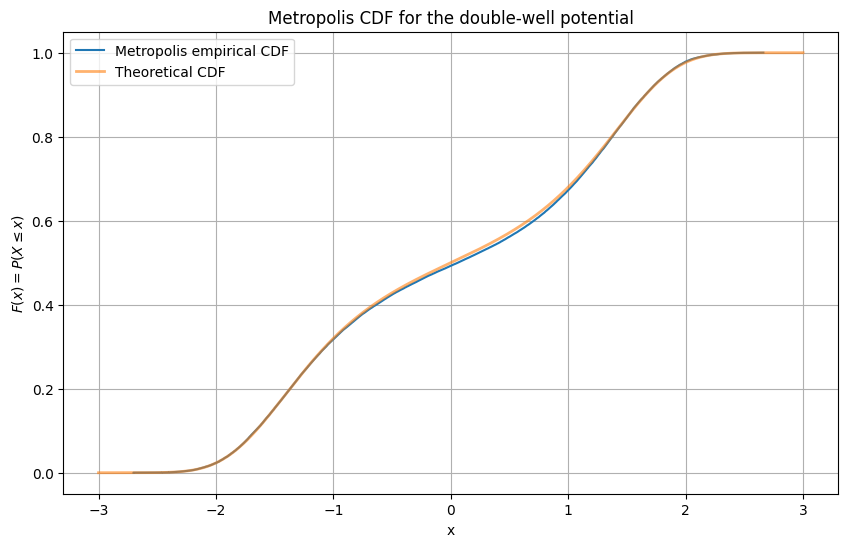

In [20]:
metropolis_double_samples = metropolis_double_trajectory[burn_in:]

metropolis_double_x_cdf, metropolis_double_y_cdf = empirical_cdf(
    metropolis_double_samples
)

x_grid_double = np.linspace(-3, 3, 4000)

theory_double_cdf = theoretical_cdf(
    x_grid_double,
    double_potential,
    temperature
)

plt.figure(figsize=(10, 6))

plt.plot(
    metropolis_double_x_cdf,
    metropolis_double_y_cdf,
    label="Metropolis empirical CDF"
)

plt.plot(
    x_grid_double,
    theory_double_cdf,
    linewidth=2,
    alpha=0.6,
    label="Theoretical CDF"
)

plt.xlabel("x")
plt.ylabel(r"$F(x) = P(X \leq x)$")
plt.title("Metropolis CDF for the double-well potential")
plt.grid()
plt.legend()
plt.show()

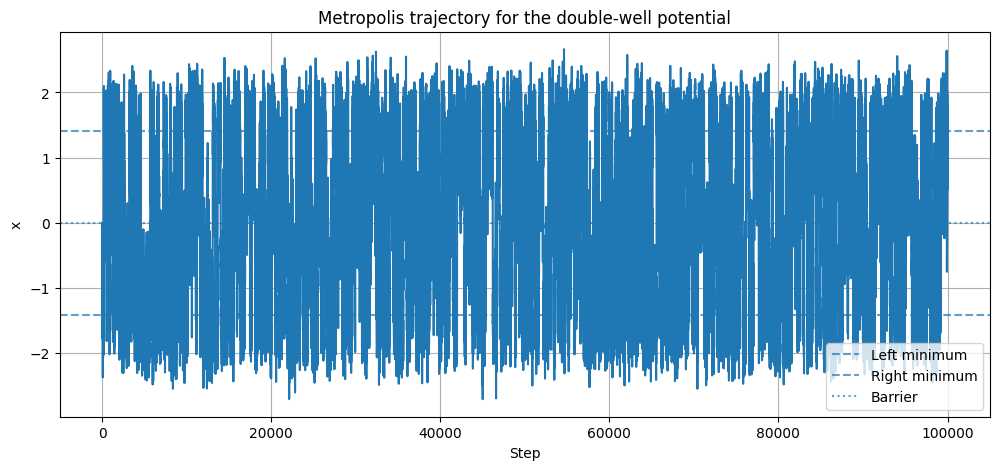

In [21]:
plt.figure(figsize=(12, 5))

plt.plot(metropolis_double_trajectory)
plt.axhline(left_minimum, linestyle="--", alpha=0.7, label="Left minimum")
plt.axhline(right_minimum, linestyle="--", alpha=0.7, label="Right minimum")
plt.axhline(barrier_position, linestyle=":", alpha=0.7, label="Barrier")

plt.xlabel("Step")
plt.ylabel("x")
plt.title("Metropolis trajectory for the double-well potential")
plt.grid()
plt.legend()
plt.show()

### Double-Well ECMC Sampling

Apply ECMC to the double-well potential by calculating the turning points and event distances.

In [22]:
def next_turning_point_double_well(x_current, velocity, a, b, tolerance=1e-12):
    """
    Finds the next turning point for a double well potential.

    Args:
        x_current (float): The current position.
        velocity (float): The current velocity.
        a (float): The coefficient for the quadratic term.
        b (float): The coefficient for the quartic term.
        tolerance (float, optional): The tolerance for floating-point comparisons. Defaults to 1e-12.

    Returns:
        float or None: The position of the next turning point, or None if no such point exists.
    """
    minimum_position = np.sqrt(a / b)

    turning_points = np.array([
        -minimum_position,
        0.0,
        minimum_position
    ])

    if velocity > 0:
        points_ahead = turning_points[turning_points > x_current + tolerance]

        if len(points_ahead) == 0:
            return None

        return points_ahead[0]

    else:
        points_ahead = turning_points[turning_points < x_current - tolerance]

        if len(points_ahead) == 0:
            return None

        return points_ahead[-1]

In [23]:
def solve_distance_to_target_potential(x_start, velocity, target_potential, potential_func, max_distance=None, tolerance=1e-12, max_iterations=100):
    """
    Solve for the distance to the target potential using a bisection method.

    Args:
        x_start (float): The starting position.
        velocity (float): The velocity.
        target_potential (float): The target potential.
        potential_func (callable): The potential function.
        max_distance (float, optional): The maximum distance to consider. Defaults to None.
        tolerance (float, optional): The tolerance for floating-point comparisons. Defaults to 1e-12.
        max_iterations (int, optional): The maximum number of iterations. Defaults to 100.

    Raises:
        RuntimeError: If the event distance cannot be bracketed.

    Returns:
        float: The distance to the target potential.
    """             
    left_distance = 0.0

    if max_distance is None:
        right_distance = 1.0

        while potential_func(x_start + velocity * right_distance) < target_potential:
            right_distance *= 2.0

            if right_distance > 10**5:
                raise RuntimeError("Could not bracket the event distance.")

    else:
        right_distance = max_distance

    for _ in range(max_iterations):

        middle_distance = 0.5 * (left_distance + right_distance)
        middle_position = x_start + velocity * middle_distance
        middle_potential = potential_func(middle_position)

        if middle_potential < target_potential:
            left_distance = middle_distance
        else:
            right_distance = middle_distance

        if right_distance - left_distance < tolerance:
            break

    return 0.5 * (left_distance + right_distance)

In [24]:
def distance_to_next_event_double_well(x_current, velocity, temperature, a, b, rng, tolerance=1e-12):
    """
    Calculate the distance to the next event in a double-well potential.

    Args:
        x_current (float): The current position.
        velocity (float): The velocity.
        temperature (float): The temperature.
        a (float): The coefficient for the quadratic term.
        b (float): The coefficient for the quartic term.
        rng (numpy.random.Generator): The random number generator.
        tolerance (float, optional): The tolerance for floating-point comparisons. Defaults to 1e-12.

    Raises:
        RuntimeError: If the event distance cannot be bracketed.

    Returns:
        float: The distance to the next event.
    """
    potential_func = lambda x: U_double(x, a, b)

    uphill_energy = rng.exponential(scale=temperature)

    total_distance = 0.0
    current_x = x_current

    while True:

        next_turning_point = next_turning_point_double_well(
            current_x,
            velocity,
            a,
            b,
            tolerance=tolerance
        )

        if next_turning_point is None:
            test_x = current_x + velocity
        else:
            test_x = 0.5 * (current_x + next_turning_point)

        moving_uphill = velocity * dU_double(test_x, a, b) > 0

        if not moving_uphill:

            if next_turning_point is None:
                raise RuntimeError("Unexpected downhill direction with no turning point ahead.")

            distance_to_turning_point = abs(next_turning_point - current_x)

            total_distance += distance_to_turning_point
            current_x = next_turning_point

        else:

            current_potential = potential_func(current_x)

            if next_turning_point is None:

                target_potential = current_potential + uphill_energy

                event_distance = solve_distance_to_target_potential(
                    x_start=current_x,
                    velocity=velocity,
                    target_potential=target_potential,
                    potential_func=potential_func,
                    max_distance=None,
                    tolerance=tolerance
                )

                return total_distance + event_distance

            else:

                turning_point_potential = potential_func(next_turning_point)
                available_uphill_energy = turning_point_potential - current_potential

                if uphill_energy <= available_uphill_energy + tolerance:

                    target_potential = current_potential + uphill_energy
                    max_distance = abs(next_turning_point - current_x)

                    event_distance = solve_distance_to_target_potential(
                        x_start=current_x,
                        velocity=velocity,
                        target_potential=target_potential,
                        potential_func=potential_func,
                        max_distance=max_distance,
                        tolerance=tolerance
                    )

                    return total_distance + event_distance

                else:

                    uphill_energy -= available_uphill_energy

                    distance_to_turning_point = abs(next_turning_point - current_x)

                    total_distance += distance_to_turning_point
                    current_x = next_turning_point

In [25]:
def run_ecmc_double_well(initial_x, num_burn_in_steps, num_samples, distance_between_samples, temperature, a, b, rng):
    """
    Run the Event-Chain Monte Carlo (ECMC) algorithm for a double-well potential.

    Args:
        initial_x (float): The initial position.
        num_burn_in_steps (int): The number of burn-in steps.
        num_samples (int): The number of samples to generate.
        distance_between_samples (float): The distance between samples.
        temperature (float): The temperature.
        a (float): The coefficient for the quadratic term.
        b (float): The coefficient for the quartic term.
        rng (numpy.random.Generator): The random number generator.

    Returns:
        numpy.ndarray: An array containing the potential and position trajectories.
    """

    current_x = initial_x

    num_iterations = num_burn_in_steps + num_samples

    potential_trajectory = np.empty(num_iterations)
    position_trajectory = np.empty(num_iterations)

    num_events = 0

    for iteration in range(num_iterations):

        velocity = rng.choice([-1, 1])

        distance_remaining = distance_between_samples

        while distance_remaining > 0:

            distance_to_event = distance_to_next_event_double_well(
                current_x,
                velocity,
                temperature,
                a,
                b,
                rng
            )

            if distance_to_event <= distance_remaining:

                current_x += velocity * distance_to_event

                distance_remaining -= distance_to_event

                velocity *= -1

                num_events += 1

            else:

                current_x += velocity * distance_remaining

                distance_remaining = 0

        potential_trajectory[iteration] = U_double(current_x, a, b)
        position_trajectory[iteration] = current_x

    print(f"Number of double-well ECMC events: {num_events}")

    return np.array([potential_trajectory, position_trajectory])

In [26]:
num_burn_in_steps = 1_000
num_samples = 10**5
distance_between_samples = 1.0
initial_x = 0.0
temperature = 1.0

ecmc_double_trajectory = run_ecmc_double_well(
    initial_x=initial_x,
    num_burn_in_steps=num_burn_in_steps,
    num_samples=num_samples,
    distance_between_samples=distance_between_samples,
    temperature=temperature,
    a=a,
    b=b,
    rng=rng
)

ecmc_double_potential_samples = ecmc_double_trajectory[0, num_burn_in_steps:]
ecmc_double_position_samples = ecmc_double_trajectory[1, num_burn_in_steps:]

Number of double-well ECMC events: 58901


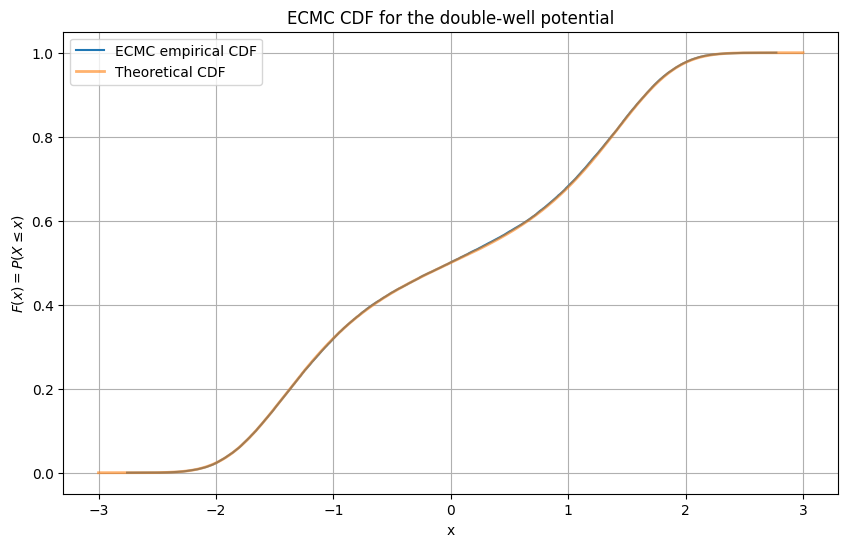

In [27]:
ecmc_double_x_cdf, ecmc_double_y_cdf = empirical_cdf(
    ecmc_double_position_samples
)

x_grid_double = np.linspace(-3, 3, 4000)

theory_double_cdf = theoretical_cdf(
    x_grid_double,
    double_potential,
    temperature
)

plt.figure(figsize=(10, 6))

plt.plot(
    ecmc_double_x_cdf,
    ecmc_double_y_cdf,
    label="ECMC empirical CDF"
)

plt.plot(
    x_grid_double,
    theory_double_cdf,
    linewidth=2,
    alpha=0.6,
    label="Theoretical CDF"
)

plt.xlabel("x")
plt.ylabel(r"$F(x) = P(X \leq x)$")
plt.title("ECMC CDF for the double-well potential")
plt.grid()
plt.legend()
plt.show()

### Double-Well Comparison

Compare the CDFs, trajectories and autocorrelation produced by Metropolis and ECMC.

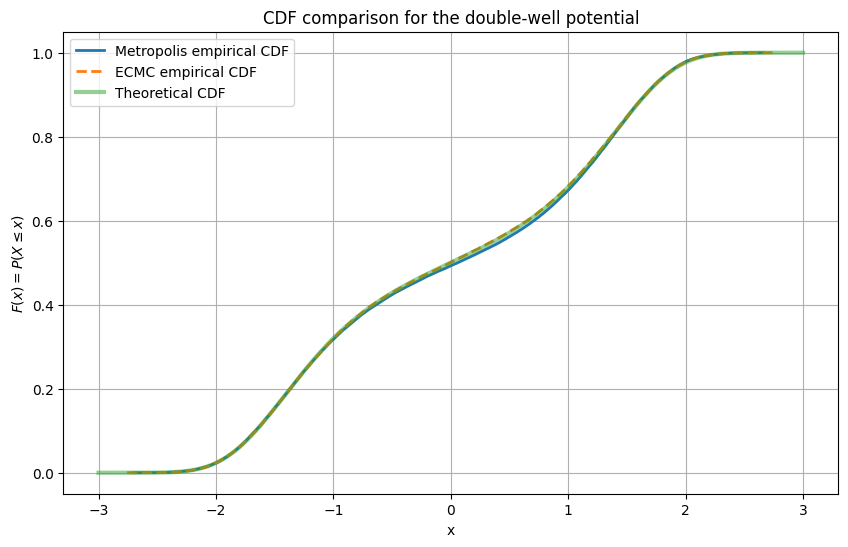

In [28]:
plt.figure(figsize=(10, 6))

plt.plot(
    metropolis_double_x_cdf,
    metropolis_double_y_cdf,
    linewidth=2,
    label="Metropolis empirical CDF"
)

plt.plot(
    ecmc_double_x_cdf,
    ecmc_double_y_cdf,
    linewidth=2,
    linestyle="--",
    label="ECMC empirical CDF"
)

plt.plot(
    x_grid_double,
    theory_double_cdf,
    linewidth=3,
    alpha=0.5,
    label="Theoretical CDF"
)

plt.xlabel("x")
plt.ylabel(r"$F(x) = P(X \leq x)$")
plt.title("CDF comparison for the double-well potential")
plt.grid()
plt.legend()
plt.show()

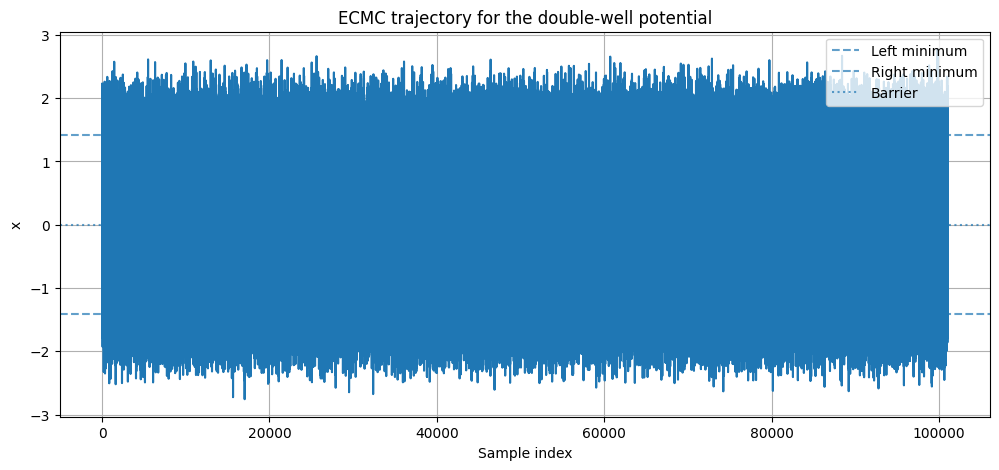

In [29]:
plt.figure(figsize=(12, 5))

plt.plot(ecmc_double_trajectory[1])
plt.axhline(left_minimum, linestyle="--", alpha=0.7, label="Left minimum")
plt.axhline(right_minimum, linestyle="--", alpha=0.7, label="Right minimum")
plt.axhline(barrier_position, linestyle=":", alpha=0.7, label="Barrier")

plt.xlabel("Sample index")
plt.ylabel("x")
plt.title("ECMC trajectory for the double-well potential")
plt.grid()
plt.legend()
plt.show()

In [30]:
metropolis_double_position_samples = metropolis_double_samples
ecmc_double_position_samples = ecmc_double_position_samples

max_lag = 100

rho_metropolis_double = normalised_autocorrelation(
    metropolis_double_position_samples,
    max_lag
)

rho_ecmc_double = normalised_autocorrelation(
    ecmc_double_position_samples,
    max_lag
)

tau_metropolis_double = estimate_iact(rho_metropolis_double)
tau_ecmc_double = estimate_iact(rho_ecmc_double)

wait_metropolis_double = int(np.ceil(tau_metropolis_double))
wait_ecmc_double = int(np.ceil(tau_ecmc_double))

lag_metropolis_double = first_crossing_lag(rho_metropolis_double)
lag_ecmc_double = first_crossing_lag(rho_ecmc_double)

print(f"Double-well Metropolis: IACT ~ {tau_metropolis_double:.3f}, wait ~ {wait_metropolis_double} steps, first e^-2 crossing lag = {lag_metropolis_double}")
print(f"Double-well ECMC: IACT ~ {tau_ecmc_double:.3f}, wait ~ {wait_ecmc_double} steps, first e^-2 crossing lag = {lag_ecmc_double}")
print(f"Efficiency ratio (Metropolis / ECMC, by IACT) ~ {tau_metropolis_double / tau_ecmc_double:.2f}x")

Double-well Metropolis: IACT ~ 104.778, wait ~ 105 steps, first e^-2 crossing lag = 100
Double-well ECMC: IACT ~ 10.288, wait ~ 11 steps, first e^-2 crossing lag = 13
Efficiency ratio (Metropolis / ECMC, by IACT) ~ 10.18x


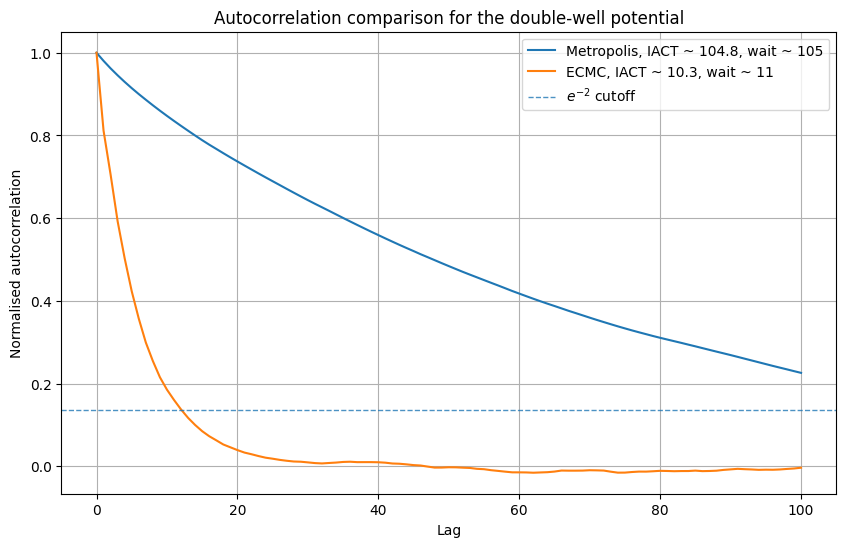

In [31]:
lags = np.arange(max_lag + 1)

plt.figure(figsize=(10, 6))

plt.plot(
    lags,
    rho_metropolis_double,
    label=f"Metropolis, IACT ~ {tau_metropolis_double:.1f}, wait ~ {wait_metropolis_double}"
)

plt.plot(
    lags,
    rho_ecmc_double,
    label=f"ECMC, IACT ~ {tau_ecmc_double:.1f}, wait ~ {wait_ecmc_double}"
)

plt.axhline(
    np.exp(-2),
    linestyle="--",
    linewidth=1,
    alpha=0.8,
    label=r"$e^{-2}$ cutoff"
)

plt.xlabel("Lag")
plt.ylabel("Normalised autocorrelation")
plt.title("Autocorrelation comparison for the double-well potential")
plt.grid()
plt.legend()
plt.show()

## ECMC Using Poisson Thinning

Use Poisson thinning to generate and accept candidate ECMC events from an upper bound on the event rate.

In [32]:
def event_rate_double_well(x, velocity, temperature, a, b):
    """
    Calculate the event rate for a double-well potential.

    Args:
        x (float): The current position.
        velocity (float): The current velocity.
        temperature (float): The temperature.
        a (float): The parameter a.
        b (float): The parameter b.

    Returns:
        float: The event rate.
    """
    return max(0.0, velocity * dU_double(x, a, b) / temperature)

def upper_bound_event_rate_double_well(x_start, velocity, max_distance, temperature, a, b, safety_factor=1.000001):
    """
    Calculate an upper bound for the event rate in a double-well potential.

    Args:
        x_start (float): The starting position.
        velocity (float): The velocity.
        max_distance (float): The maximum distance to consider.
        temperature (float): The temperature.
        a (float): The parameter a.
        b (float): The parameter b.
        safety_factor (float, optional): A safety factor to ensure the upper bound is valid. Defaults to 1.000001.

    Returns:
        float: The upper bound for the event rate.
    """
    x_end = x_start + velocity * max_distance

    x_low = min(x_start, x_end)
    x_high = max(x_start, x_end)

    # Candidate points include endpoints.
    candidate_points = [x_low, x_high]

    # For U'(x) = -a x + b x^3, the derivative of U' has roots
    # at x = +-sqrt(a / (3b)).
    critical = np.sqrt(a / (3*b))

    for point in [-critical, critical]:
        if x_low <= point <= x_high:
            candidate_points.append(point)

    rates = [
        event_rate_double_well(x, velocity, temperature, a, b)
        for x in candidate_points
    ]

    return safety_factor * max(rates)

def distance_to_next_event_double_well_thinning(x_current, velocity, max_distance, temperature, a, b, rng):
    """
    Calculate the distance to the next event in a double-well potential using thinning.

    Args:
        x_current (float): The current position.
        velocity (float): The velocity.
        max_distance (float): The maximum distance to consider.
        temperature (float): The temperature.
        a (float): The parameter a.
        b (float): The parameter b.
        rng (numpy.random.Generator): A random number generator.

    Returns:
        float: The distance to the next event, or None if no event occurs within the maximum distance.
    """
    rate_bound = upper_bound_event_rate_double_well(
        x_start=x_current,
        velocity=velocity,
        max_distance=max_distance,
        temperature=temperature,
        a=a,
        b=b
    )

    if rate_bound <= 0.0:
        return None

    traveled_distance = 0.0

    while traveled_distance < max_distance:

        # Candidate event from a homogeneous Poisson process with rate M.
        candidate_step = rng.exponential(scale=1.0 / rate_bound)
        traveled_distance += candidate_step

        if traveled_distance > max_distance:
            return None

        candidate_x = x_current + velocity * traveled_distance

        true_rate = event_rate_double_well(
            candidate_x,
            velocity,
            temperature,
            a,
            b
        )

        acceptance_probability = min(1.0, true_rate / rate_bound)

        if rng.random() < acceptance_probability:
            return traveled_distance

    return None

def run_ecmc_double_well_thinning(initial_x, num_burn_in_steps, num_samples, distance_between_samples, temperature, a, b, rng):
    """
    Run the Event-Chain Monte Carlo (ECMC) algorithm for a double-well potential using thinning.

    Args:
        initial_x (float): The initial position.
        num_burn_in_steps (int): The number of burn-in steps.
        num_samples (int): The number of samples to generate.
        distance_between_samples (float): The distance between samples.
        temperature (float): The temperature.
        a (float): The parameter a.
        b (float): The parameter b.
        rng (numpy.random.Generator): A random number generator.
        
    Returns:
        np.ndarray: An array containing the potential and position trajectories.
    """
    current_x = initial_x

    num_iterations = num_burn_in_steps + num_samples

    potential_trajectory = np.empty(num_iterations)
    position_trajectory = np.empty(num_iterations)

    num_events = 0

    for iteration in range(num_iterations):

        velocity = rng.choice([-1, 1])
        distance_remaining = distance_between_samples

        while distance_remaining > 0:

            distance_to_event = distance_to_next_event_double_well_thinning(
                x_current=current_x,
                velocity=velocity,
                max_distance=distance_remaining,
                temperature=temperature,
                a=a,
                b=b,
                rng=rng
            )

            if distance_to_event is None:
                current_x += velocity * distance_remaining
                distance_remaining = 0

            else:
                current_x += velocity * distance_to_event
                distance_remaining -= distance_to_event

                velocity *= -1
                num_events += 1

        potential_trajectory[iteration] = U_double(current_x, a, b)
        position_trajectory[iteration] = current_x

    print(f"Number of accepted ECMC events: {num_events}")

    return np.array([potential_trajectory, position_trajectory])

In [33]:
temperature = 1.0
num_burn_in_steps = 1_000
num_samples = 10**5
distance_between_samples = 1.0
initial_x = 0.0

ecmc_double_thinning_trajectory = run_ecmc_double_well_thinning(
    initial_x=initial_x,
    num_burn_in_steps=num_burn_in_steps,
    num_samples=num_samples,
    distance_between_samples=distance_between_samples,
    temperature=temperature,
    a=a,
    b=b,
    rng=rng
)

ecmc_double_thinning_samples = ecmc_double_thinning_trajectory[1, num_burn_in_steps:]

Number of accepted ECMC events: 59166


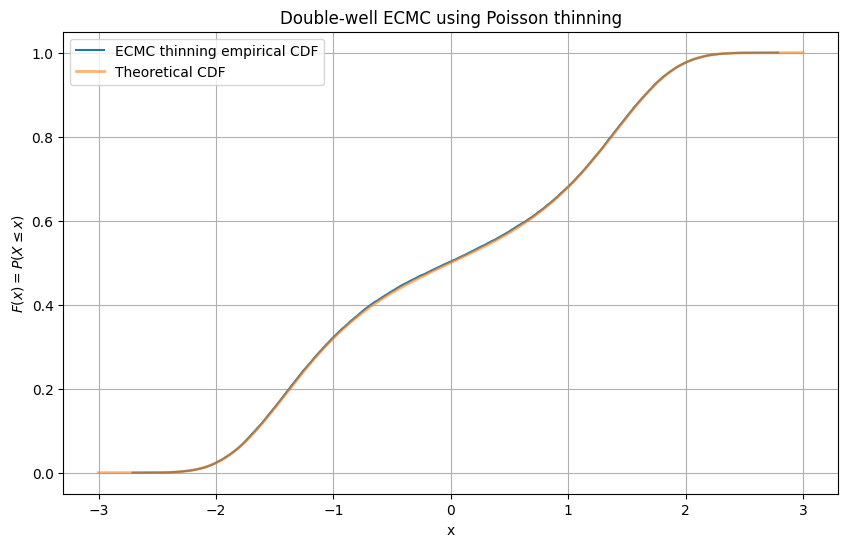

In [34]:
ecmc_double_thinning_x_cdf, ecmc_double_thinning_y_cdf = empirical_cdf(
    ecmc_double_thinning_samples
)

x_grid_double = np.linspace(-3, 3, 4000)

theory_double_cdf = theoretical_cdf(
    x_grid_double,
    double_potential,
    temperature
)

plt.figure(figsize=(10, 6))

plt.plot(
    ecmc_double_thinning_x_cdf,
    ecmc_double_thinning_y_cdf,
    label="ECMC thinning empirical CDF"
)

plt.plot(
    x_grid_double,
    theory_double_cdf,
    linewidth=2,
    alpha=0.6,
    label="Theoretical CDF"
)

plt.xlabel("x")
plt.ylabel(r"$F(x) = P(X \leq x)$")
plt.title("Double-well ECMC using Poisson thinning")
plt.grid()
plt.legend()
plt.show()

## Temperature Experiments

Compare Metropolis and ECMC across a range of temperatures.

In [35]:
def run_double_well_temperature_experiment(temperature, a, b, num_burn_in_steps, num_samples, distance_between_samples, metropolis_proposal_width, initial_x, seed, max_lag=100):
    """
    Run a temperature experiment for the double-well potential using both Metropolis and ECMC methods.

    Args:
        temperature (float): The temperature at which to run the experiment.
        a (float): The parameter a.
        b (float): The parameter b.
        num_burn_in_steps (int): The number of burn-in steps.
        num_samples (int): The number of samples to generate.
        distance_between_samples (float): The distance between samples.
        metropolis_proposal_width (float): The width of the Metropolis proposal distribution.
        initial_x (float): The initial position.
        seed (int): The random seed.
        max_lag (int, optional): The maximum lag for autocorrelation analysis. Defaults to 100.

    Returns:
        dict: A dictionary containing the results of the experiment.
    """
    # Use a separate random number generator for this temperature.
    # This makes each temperature result reproducible on its own.
    local_rng = np.random.default_rng(seed)

    double_potential = lambda x: U_double(x, a, b)

    # Run Metropolis.
    metropolis_trajectory, metropolis_acceptance_rate = run_metropolis(
        initial_x=initial_x,
        num_steps=num_burn_in_steps + num_samples,
        proposal_width=metropolis_proposal_width,
        temperature=temperature,
        potential_func=double_potential,
        rng=local_rng
    )

    metropolis_samples = metropolis_trajectory[num_burn_in_steps:num_burn_in_steps + num_samples]

    # Run ECMC with Poisson thinning.
    ecmc_trajectory = run_ecmc_double_well_thinning(
        initial_x=initial_x,
        num_burn_in_steps=num_burn_in_steps,
        num_samples=num_samples,
        distance_between_samples=distance_between_samples,
        temperature=temperature,
        a=a,
        b=b,
        rng=local_rng
    )

    ecmc_samples = ecmc_trajectory[1, num_burn_in_steps:]

    # CDFs.
    metropolis_x_cdf, metropolis_y_cdf = empirical_cdf(metropolis_samples)
    ecmc_x_cdf, ecmc_y_cdf = empirical_cdf(ecmc_samples)

    x_grid = np.linspace(-3, 3, 4000)

    theory_cdf = theoretical_cdf(
        x_grid,
        double_potential,
        temperature
    )

    # Autocorrelation.
    rho_metropolis = normalised_autocorrelation(
        metropolis_samples,
        max_lag
    )

    rho_ecmc = normalised_autocorrelation(
        ecmc_samples,
        max_lag
    )

    tau_metropolis = estimate_iact(rho_metropolis)
    tau_ecmc = estimate_iact(rho_ecmc)

    lag_metropolis = first_crossing_lag(rho_metropolis)
    lag_ecmc = first_crossing_lag(rho_ecmc)

    return {
        "temperature": temperature,
        "metropolis_trajectory": metropolis_trajectory,
        "metropolis_samples": metropolis_samples,
        "metropolis_acceptance_rate": metropolis_acceptance_rate,
        "metropolis_x_cdf": metropolis_x_cdf,
        "metropolis_y_cdf": metropolis_y_cdf,
        "rho_metropolis": rho_metropolis,
        "tau_metropolis": tau_metropolis,
        "lag_metropolis": lag_metropolis,
        "ecmc_trajectory": ecmc_trajectory,
        "ecmc_samples": ecmc_samples,
        "ecmc_x_cdf": ecmc_x_cdf,
        "ecmc_y_cdf": ecmc_y_cdf,
        "rho_ecmc": rho_ecmc,
        "tau_ecmc": tau_ecmc,
        "lag_ecmc": lag_ecmc,
        "x_grid": x_grid,
        "theory_cdf": theory_cdf
    }

### Running the Temperature Experiments

Run both algorithms at each temperature and record their acceptance rates, autocorrelation times and crossing lags.

In [36]:
temperatures = [
    1.5,
    1.2,
    1.0,
    0.8,
    0.7,
    0.6,
    0.5,
    0.4,
    0.3,
    0.25,
    0.2
]

max_lag = 5_000

results = {}
records = []

for index, temp in enumerate(temperatures):

    print(f"Running temperature T = {temp}")

    result = run_double_well_temperature_experiment(
        temperature=temp,
        a=a,
        b=b,
        num_burn_in_steps=1_000,
        num_samples=10**5,
        distance_between_samples=1.0,
        metropolis_proposal_width=1.0,
        initial_x=0.0,
        seed=42 + index,
        max_lag=max_lag
    )

    results[temp] = result

    records.append({
        "Temperature": temp,
        "Metropolis Acceptance (%)": (
            100 * result["metropolis_acceptance_rate"]
        ),
        "Metropolis IACT": result["tau_metropolis"],
        "ECMC IACT": result["tau_ecmc"],
        "Metropolis Crossing Lag": result["lag_metropolis"],
        "ECMC Crossing Lag": result["lag_ecmc"],
        "IACT Ratio": (
            result["tau_metropolis"]
            / result["tau_ecmc"]
        )
    })

df = pd.DataFrame(
    records,
    columns=[
        "Temperature",
        "Metropolis Acceptance (%)",
        "Metropolis IACT",
        "ECMC IACT",
        "Metropolis Crossing Lag",
        "ECMC Crossing Lag",
        "IACT Ratio"
    ]
)

print(df.to_string(index=False))

Running temperature T = 1.5
Number of accepted ECMC events: 46038
Running temperature T = 1.2
Number of accepted ECMC events: 52799
Running temperature T = 1.0
Number of accepted ECMC events: 58907
Running temperature T = 0.8
Number of accepted ECMC events: 68666
Running temperature T = 0.7
Number of accepted ECMC events: 74732
Running temperature T = 0.6
Number of accepted ECMC events: 83192
Running temperature T = 0.5
Number of accepted ECMC events: 94707
Running temperature T = 0.4
Number of accepted ECMC events: 110484
Running temperature T = 0.3
Number of accepted ECMC events: 133324
Running temperature T = 0.25
Number of accepted ECMC events: 149471
Running temperature T = 0.2
Number of accepted ECMC events: 170771
 Temperature  Metropolis Acceptance (%)  Metropolis IACT  ECMC IACT  Metropolis Crossing Lag  ECMC Crossing Lag  IACT Ratio
        1.50                  88.897030       111.132243   8.960393                      132                 11   12.402608
        1.20         

### CDF Comparison Across Temperatures

Compare the empirical and theoretical CDFs at each temperature.

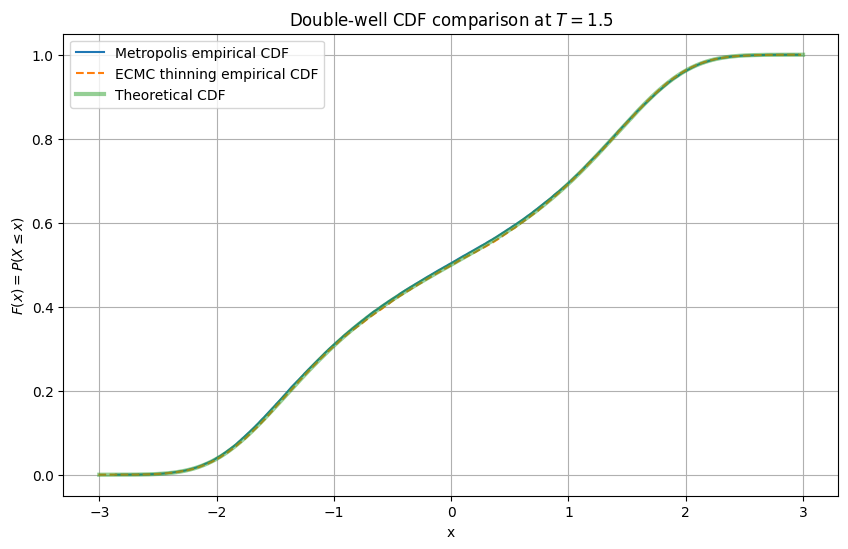

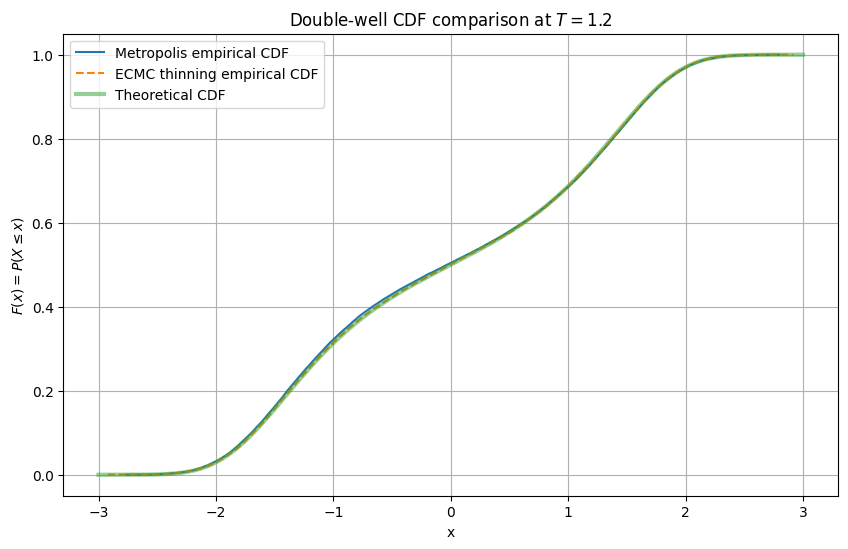

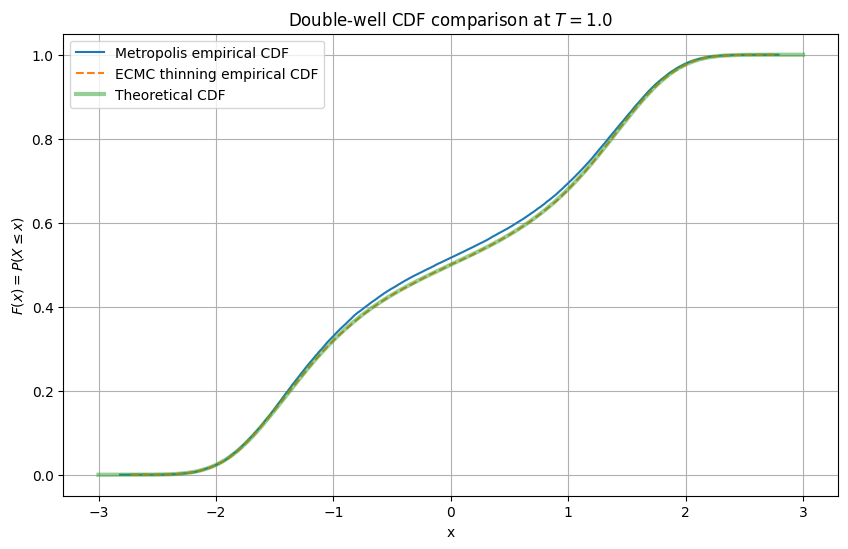

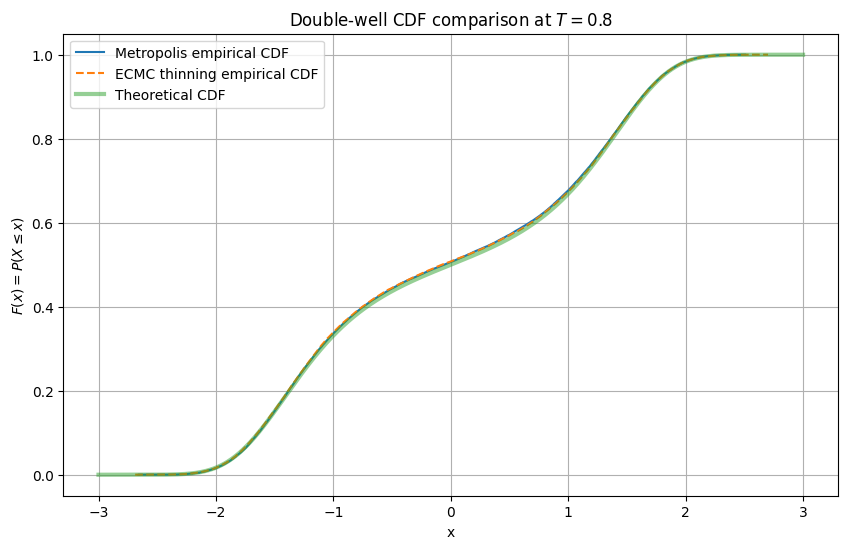

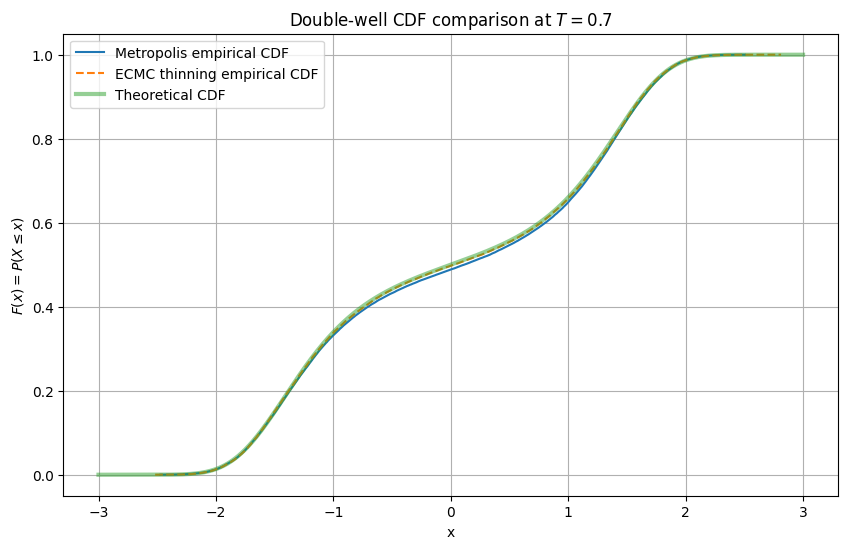

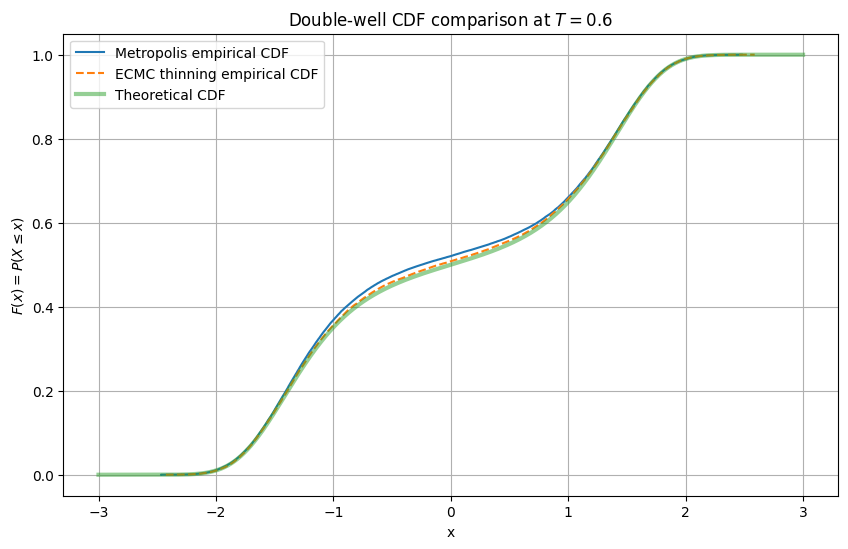

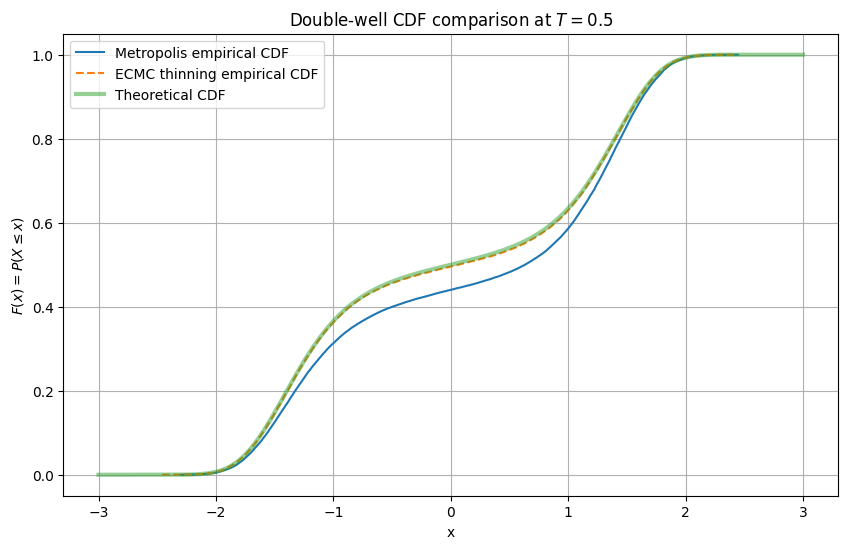

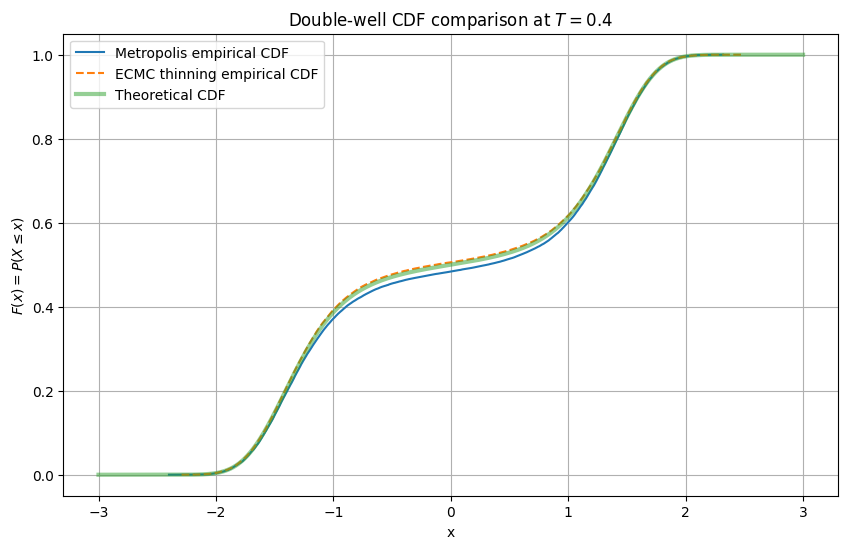

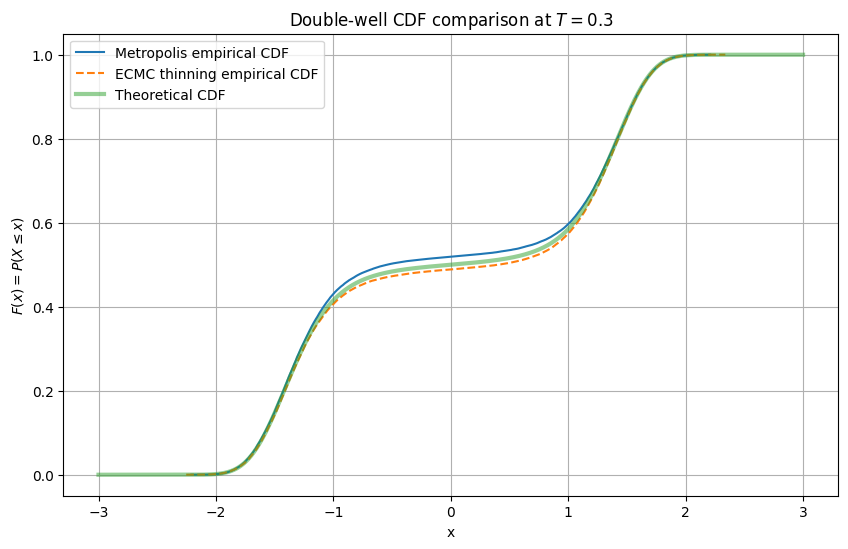

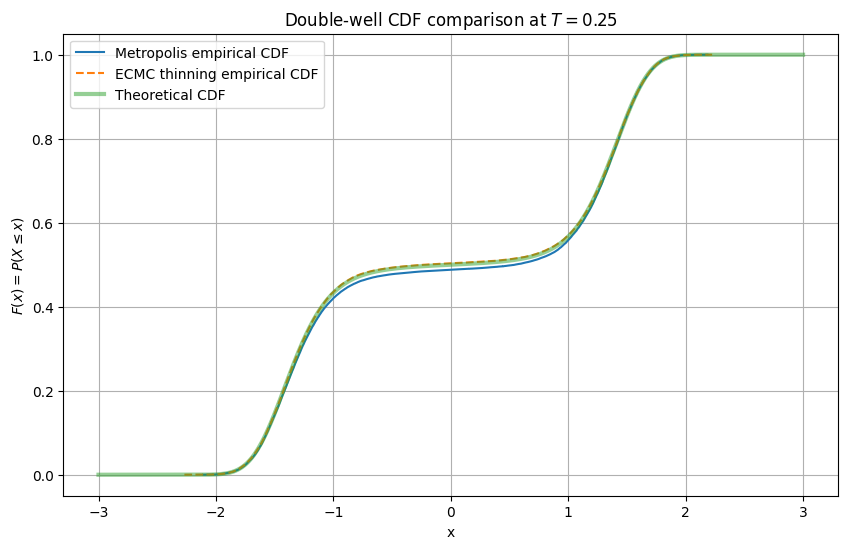

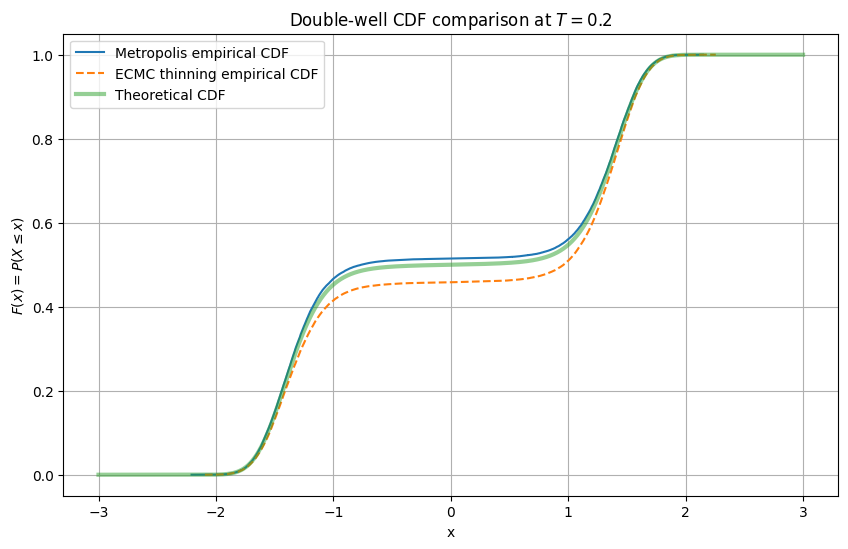

In [37]:
for temp in temperatures:

    result = results[temp]

    plt.figure(figsize=(10, 6))

    plt.plot(
        result["metropolis_x_cdf"],
        result["metropolis_y_cdf"],
        label="Metropolis empirical CDF"
    )

    plt.plot(
        result["ecmc_x_cdf"],
        result["ecmc_y_cdf"],
        linestyle="--",
        label="ECMC thinning empirical CDF"
    )

    plt.plot(
        result["x_grid"],
        result["theory_cdf"],
        linewidth=3,
        alpha=0.5,
        label="Theoretical CDF"
    )

    plt.xlabel("x")
    plt.ylabel(r"$F(x) = P(X \leq x)$")
    plt.title(fr"Double-well CDF comparison at $T={temp}$")
    plt.grid()
    plt.legend()
    plt.show()

### Trajectory Comparison Across Temperatures

Examine how frequently each algorithm moves between the two wells.

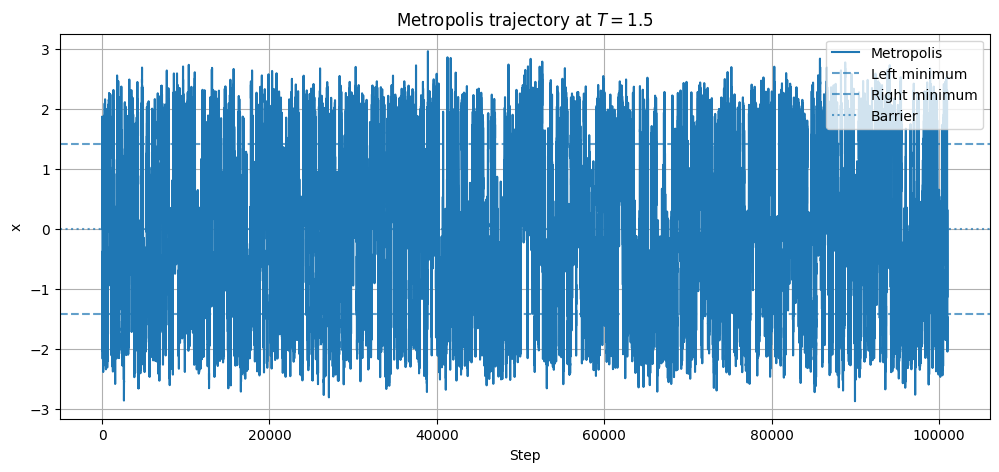

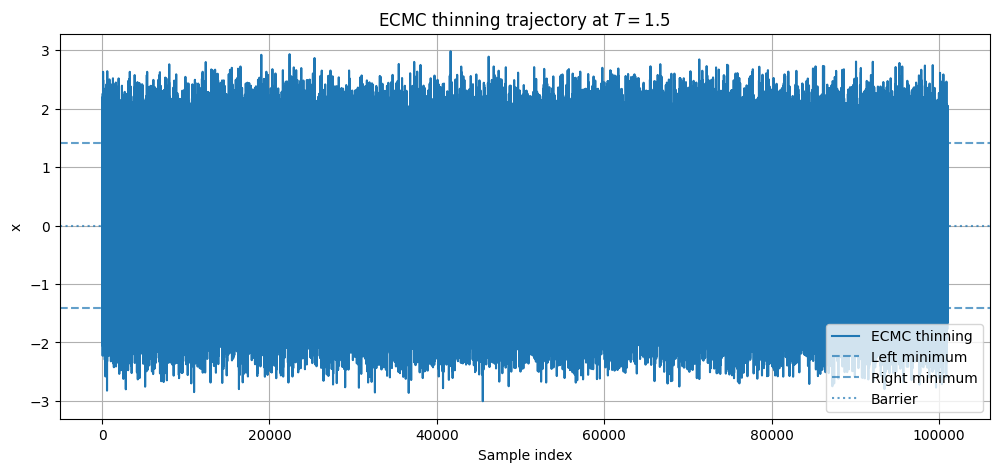

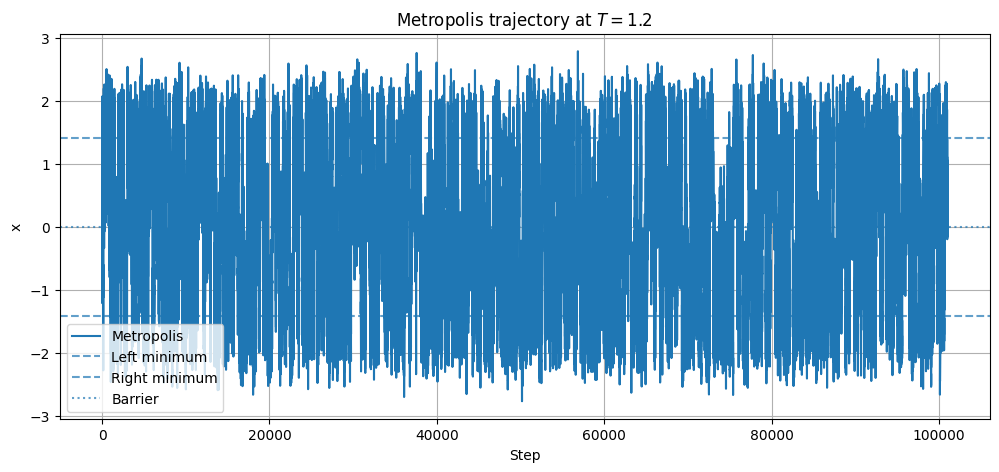

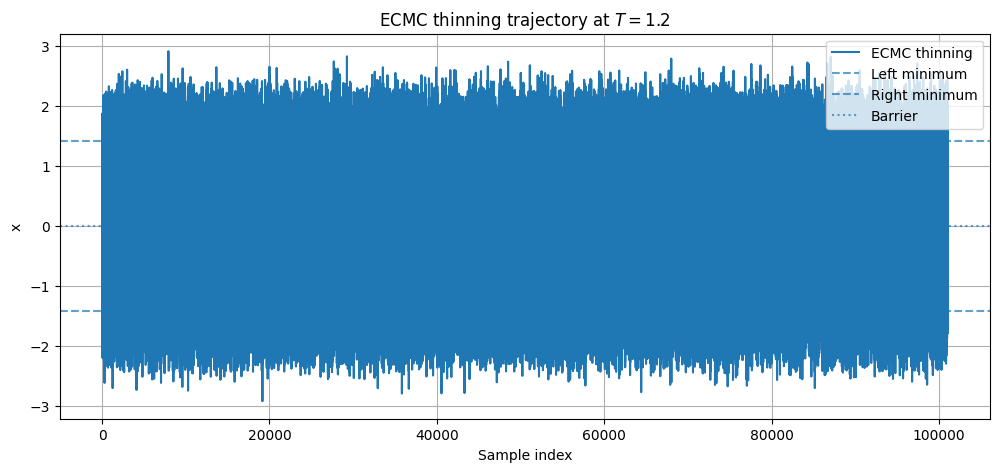

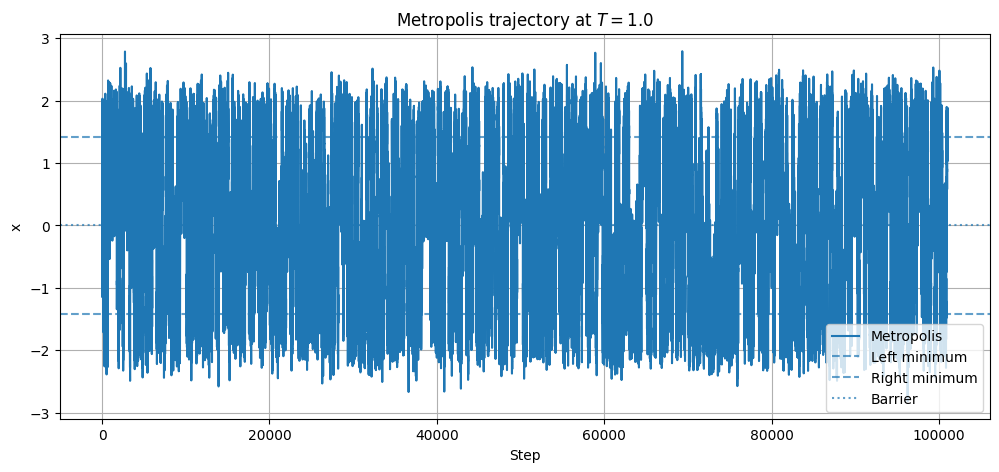

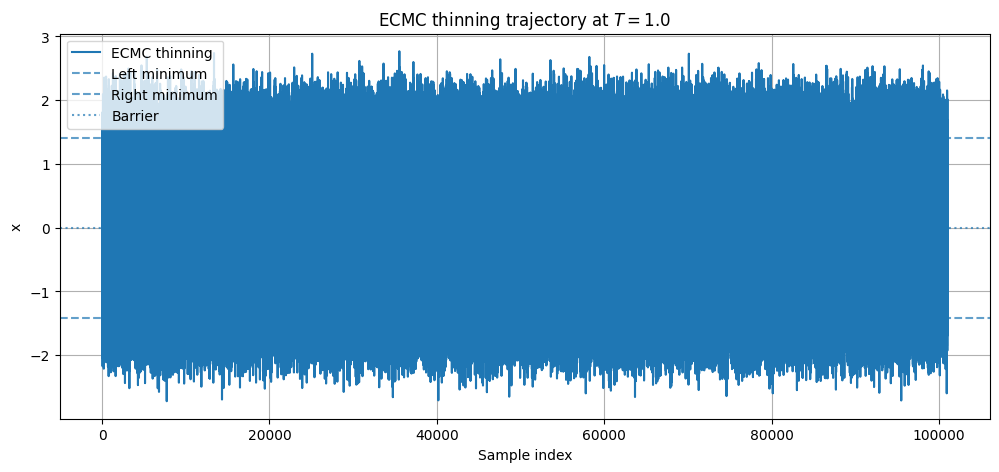

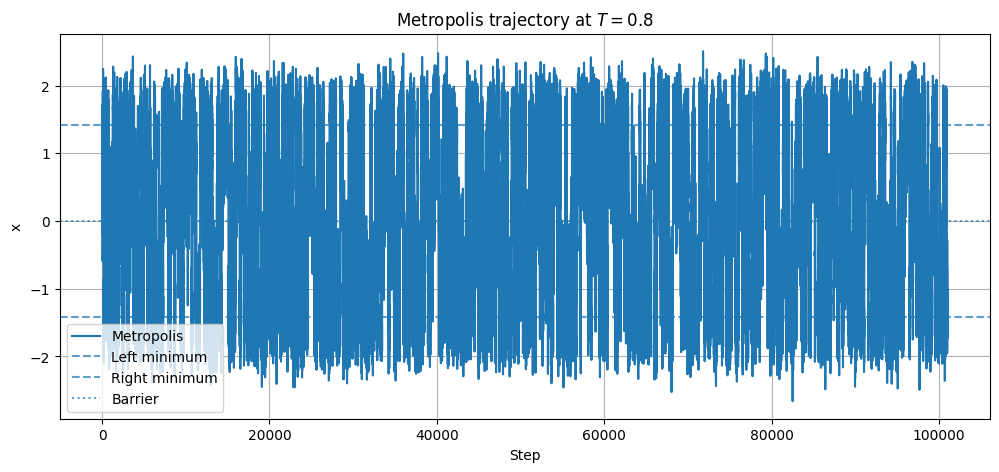

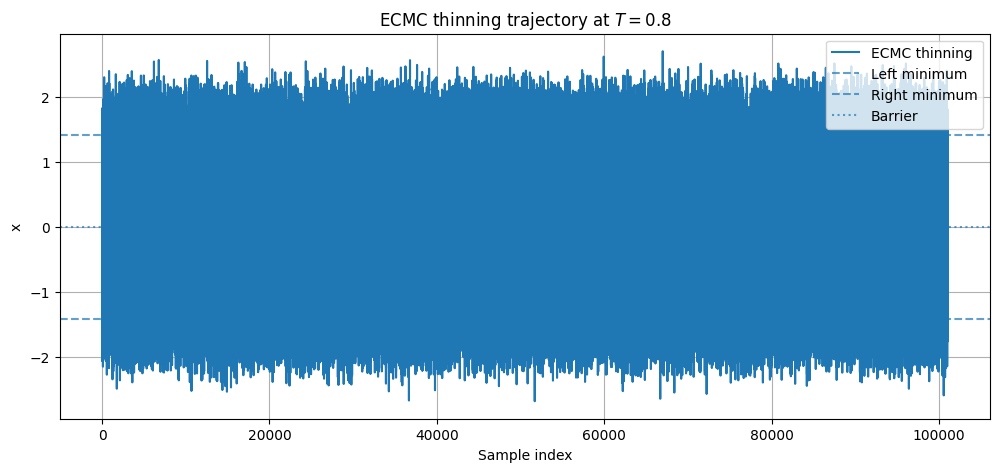

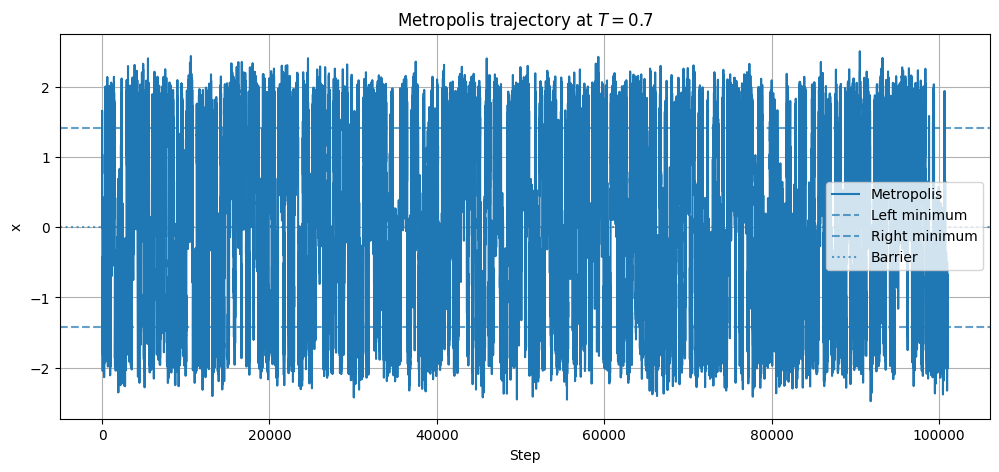

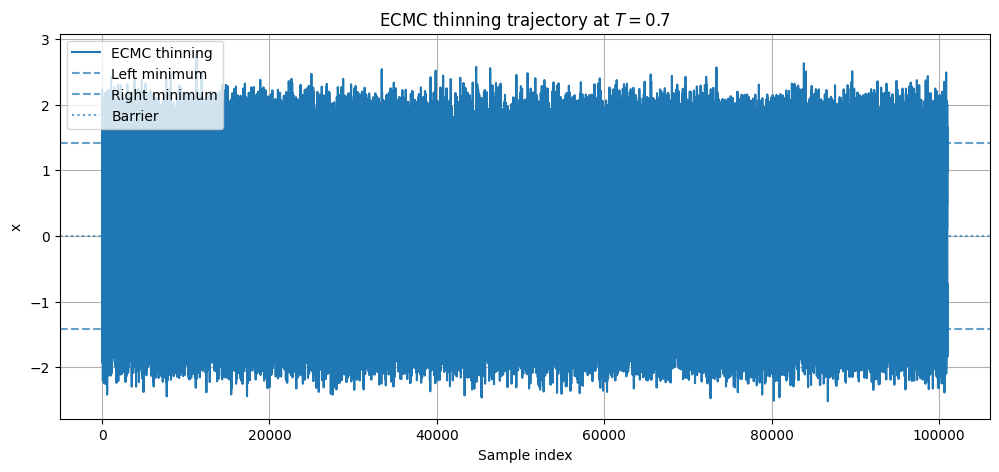

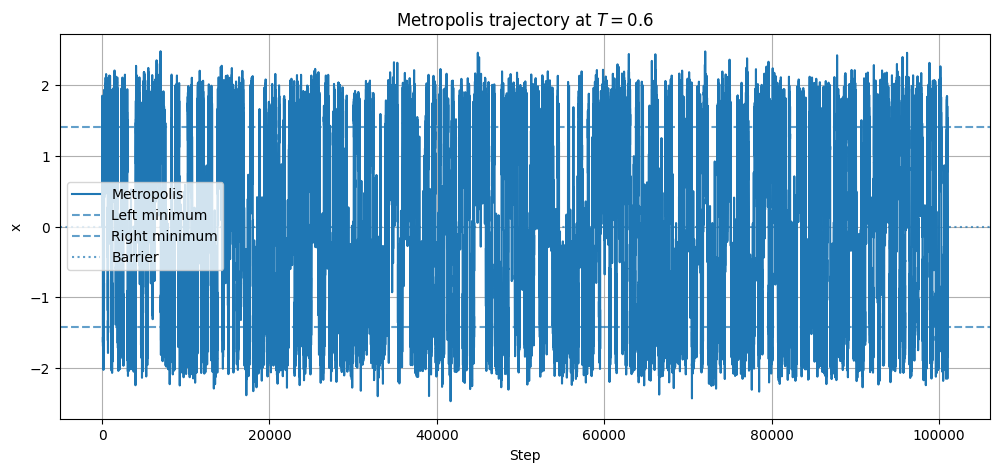

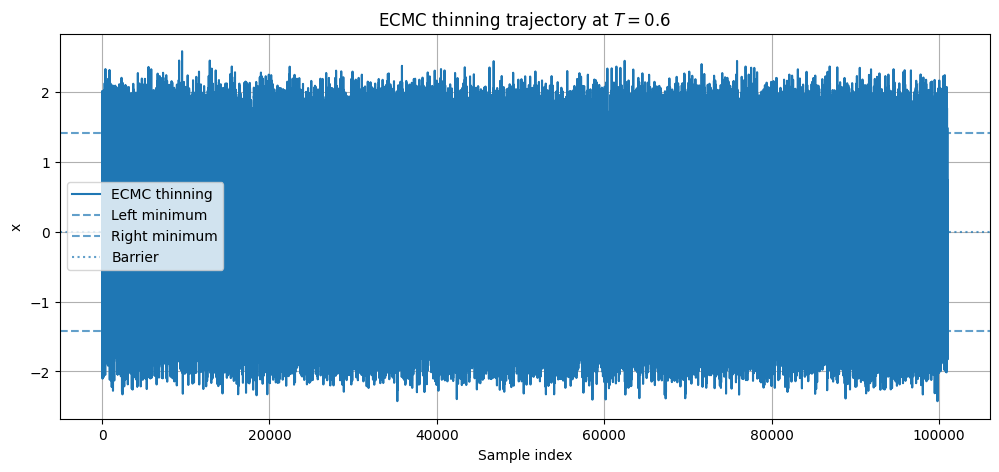

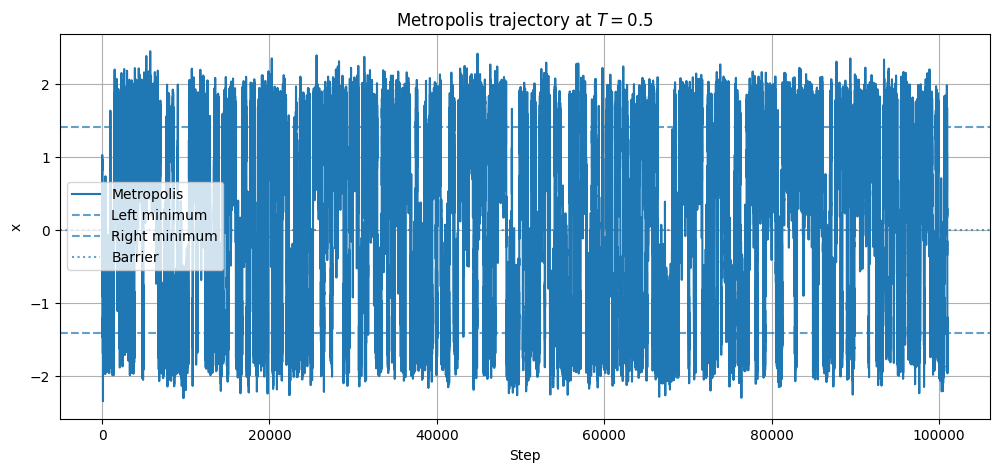

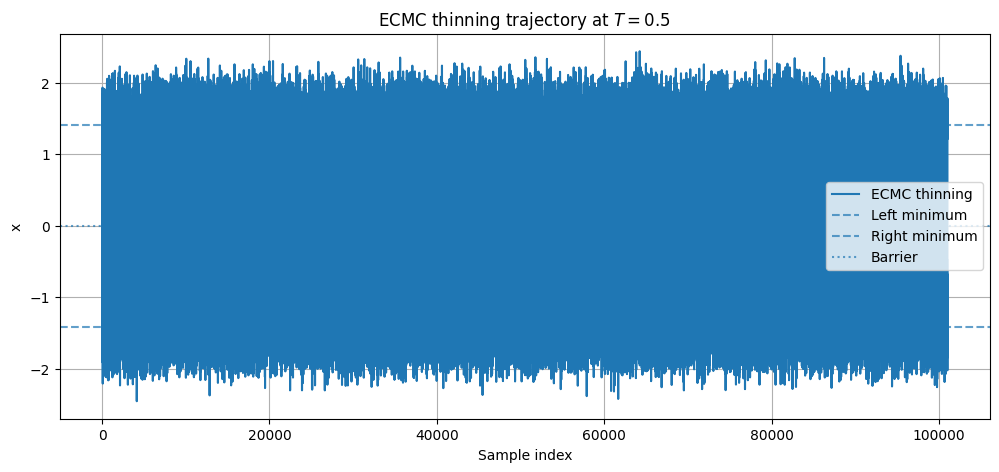

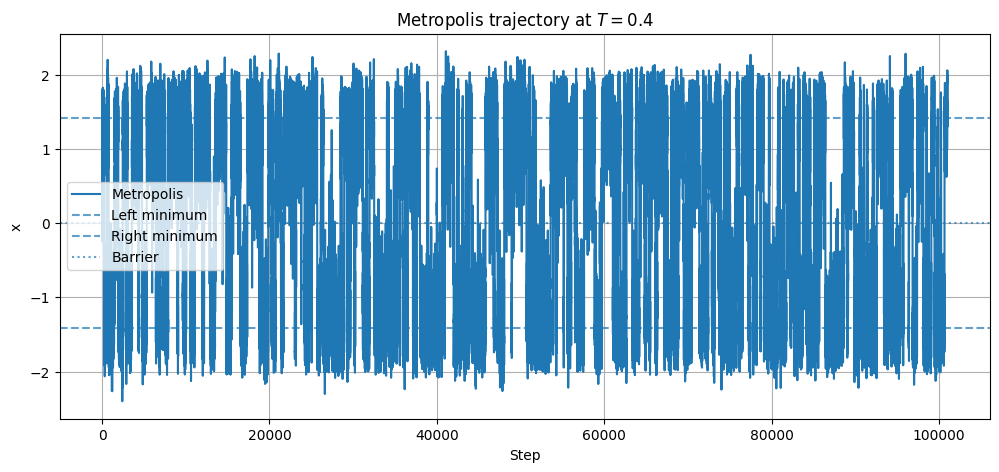

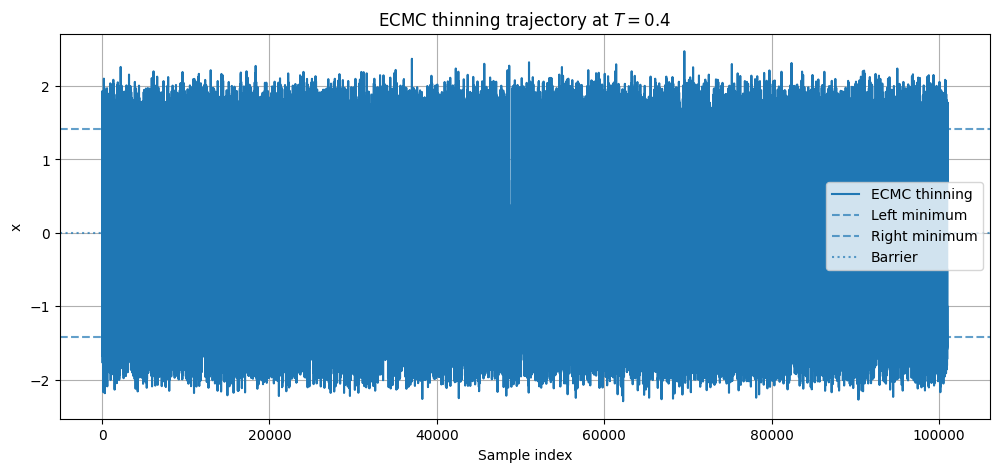

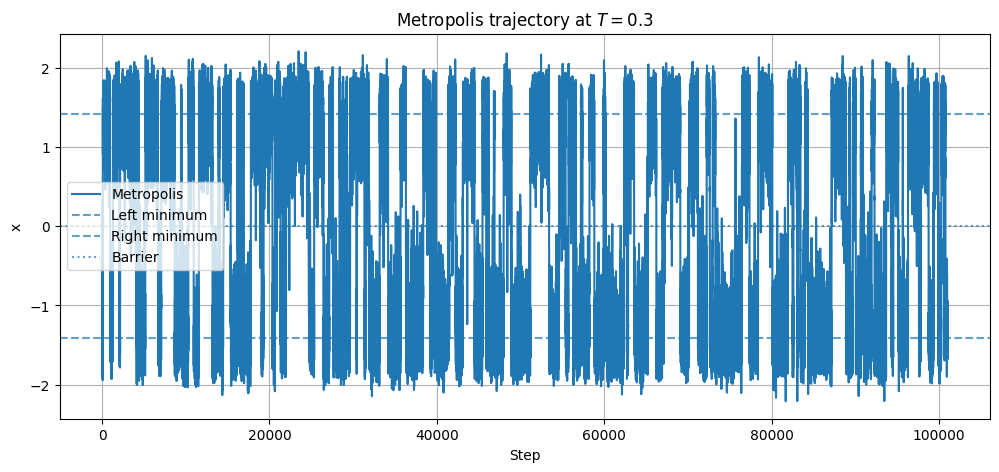

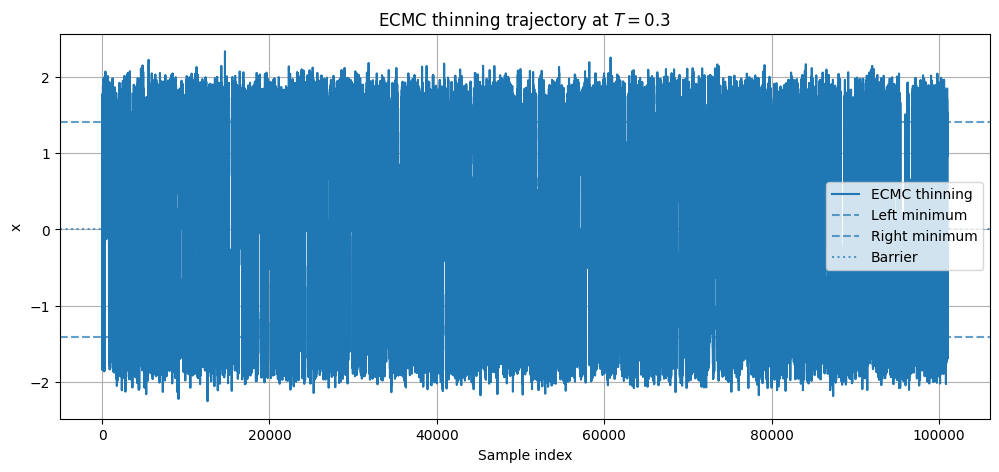

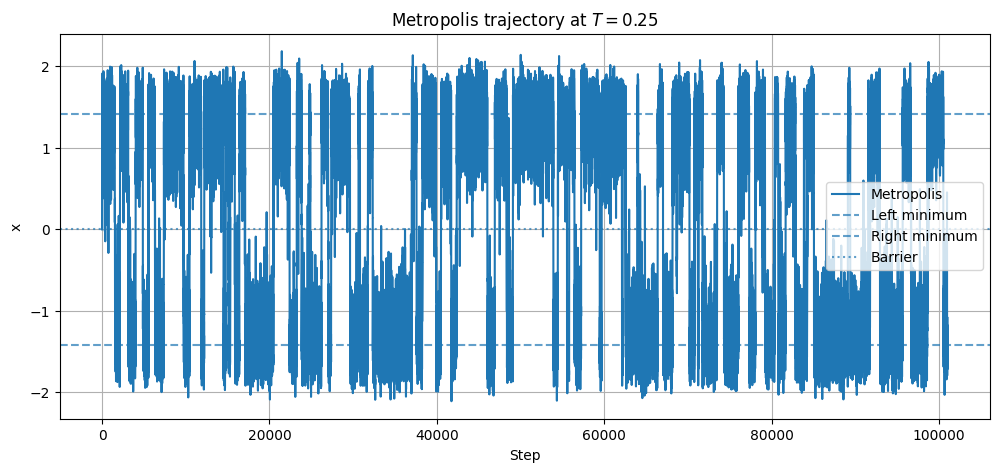

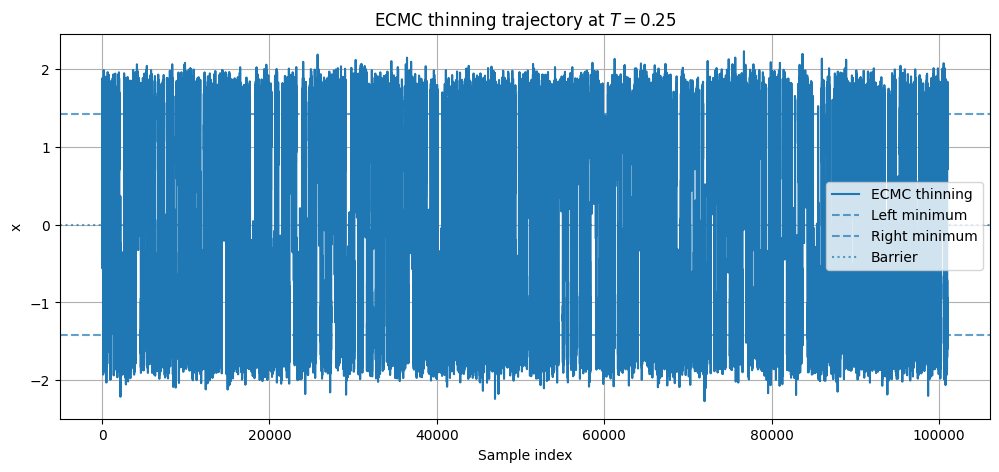

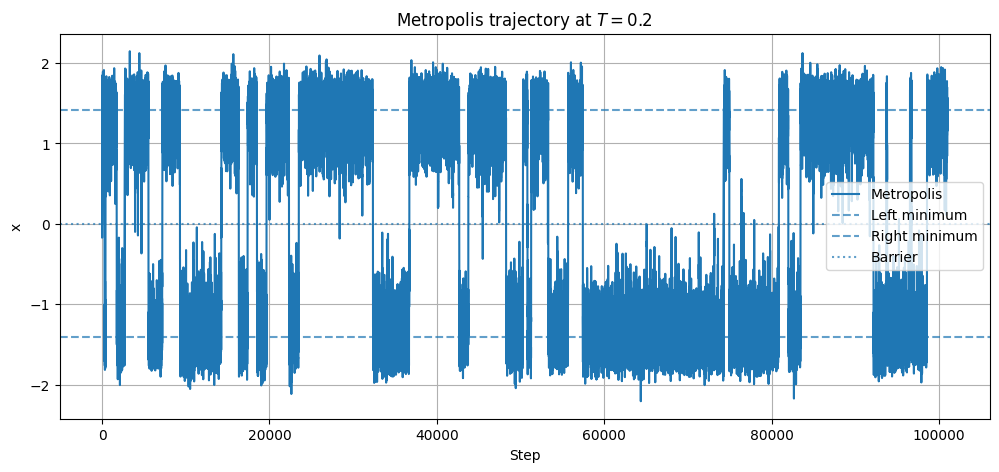

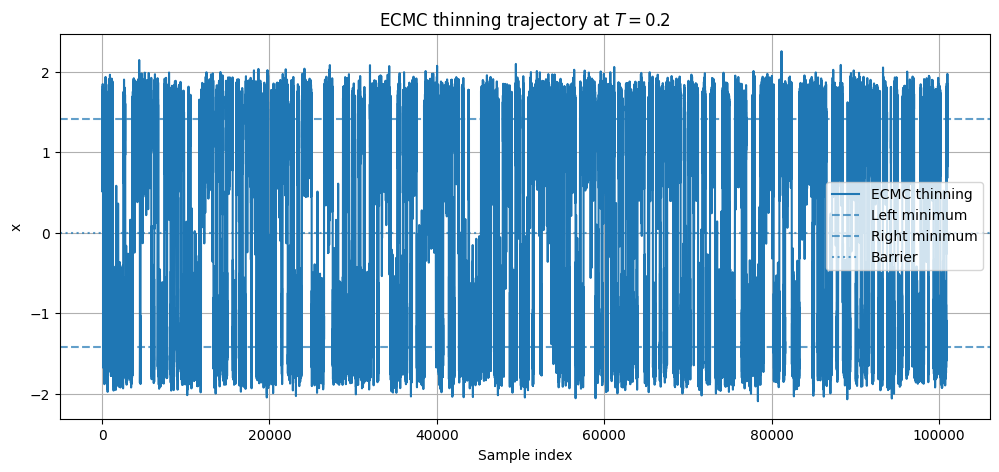

In [38]:
for temp in temperatures:

    result = results[temp]

    plt.figure(figsize=(12, 5))

    plt.plot(
        result["metropolis_trajectory"],
        label="Metropolis"
    )

    plt.axhline(left_minimum, linestyle="--", alpha=0.7, label="Left minimum")
    plt.axhline(right_minimum, linestyle="--", alpha=0.7, label="Right minimum")
    plt.axhline(barrier_position, linestyle=":", alpha=0.7, label="Barrier")

    plt.xlabel("Step")
    plt.ylabel("x")
    plt.title(fr"Metropolis trajectory at $T={temp}$")
    plt.grid()
    plt.legend()
    plt.show()

    plt.figure(figsize=(12, 5))

    plt.plot(
        result["ecmc_trajectory"][1],
        label="ECMC thinning"
    )

    plt.axhline(left_minimum, linestyle="--", alpha=0.7, label="Left minimum")
    plt.axhline(right_minimum, linestyle="--", alpha=0.7, label="Right minimum")
    plt.axhline(barrier_position, linestyle=":", alpha=0.7, label="Barrier")

    plt.xlabel("Sample index")
    plt.ylabel("x")
    plt.title(fr"ECMC thinning trajectory at $T={temp}$")
    plt.grid()
    plt.legend()
    plt.show()

### Autocorrelation Comparison Across Temperatures

Compare how quickly the autocorrelation decays for each algorithm and temperature.

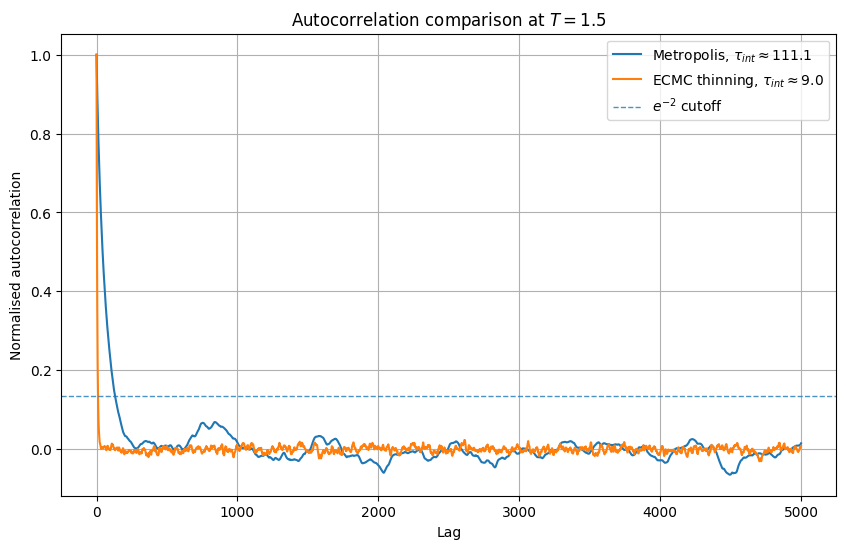

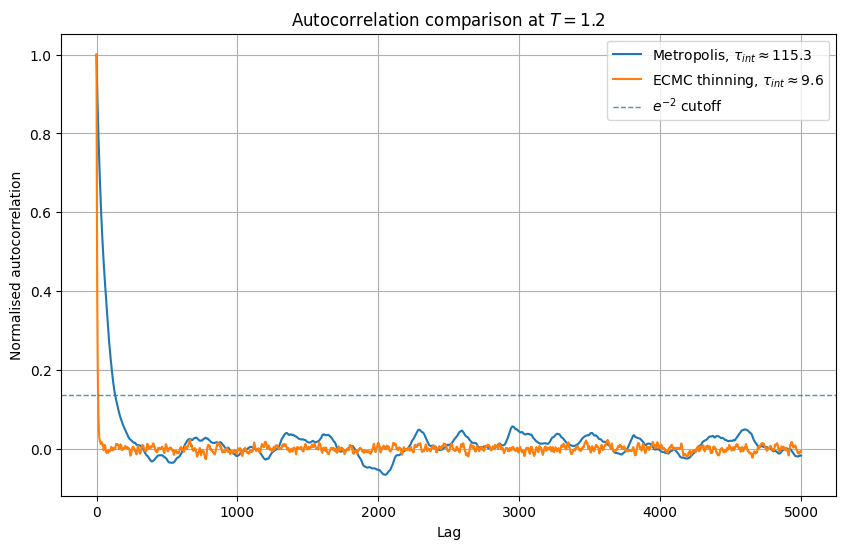

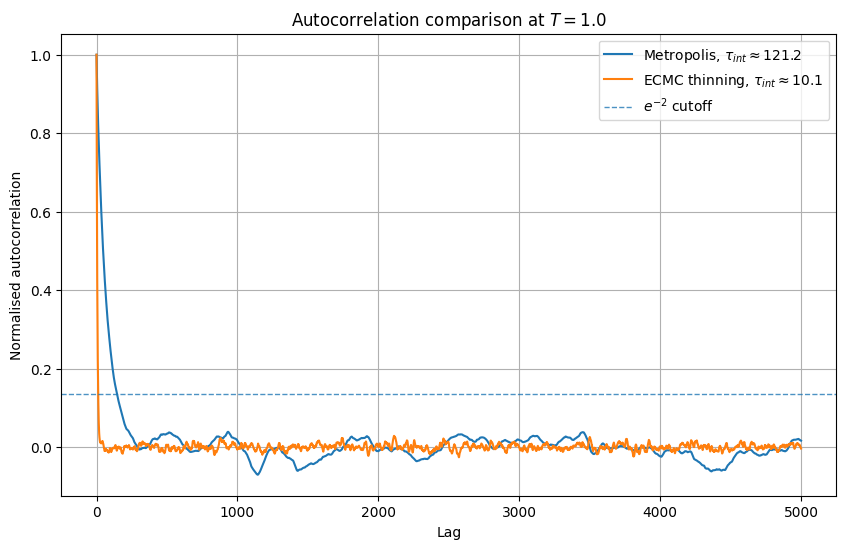

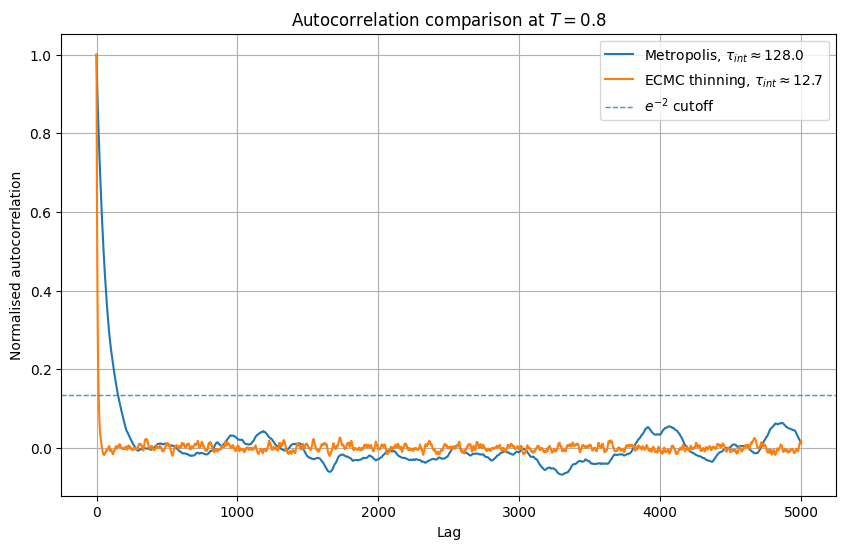

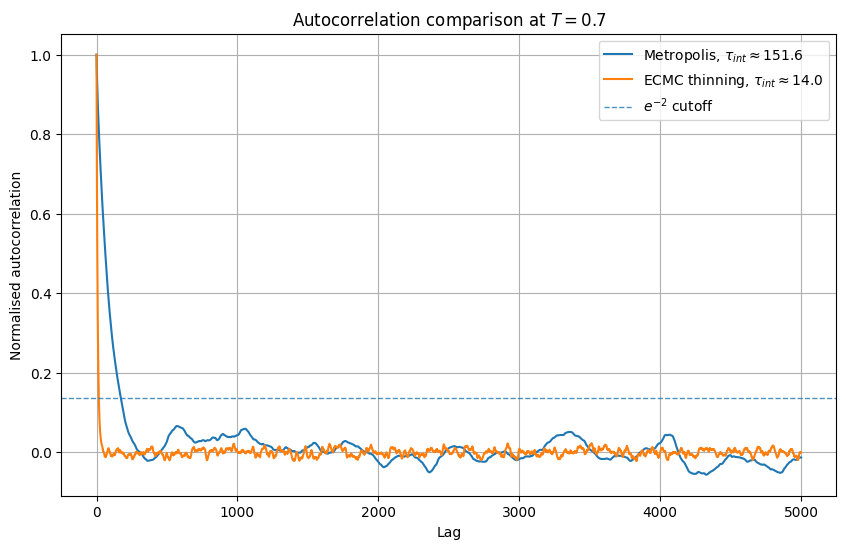

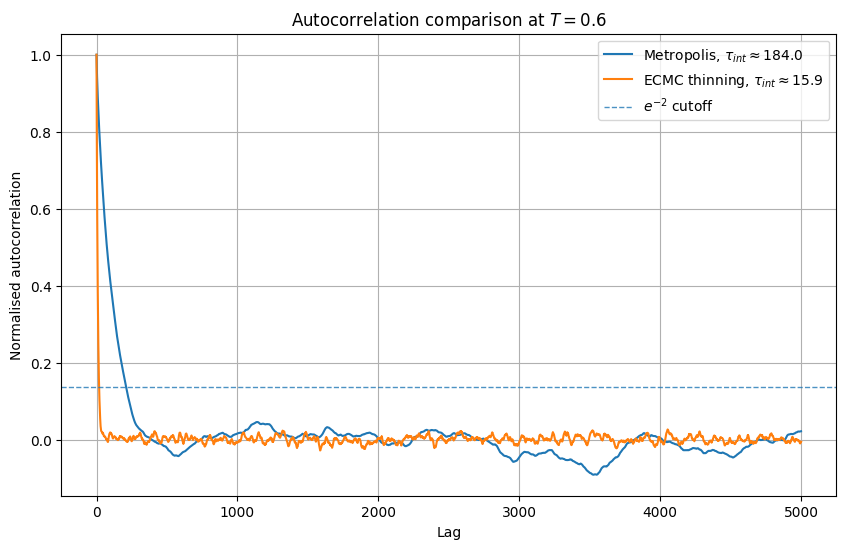

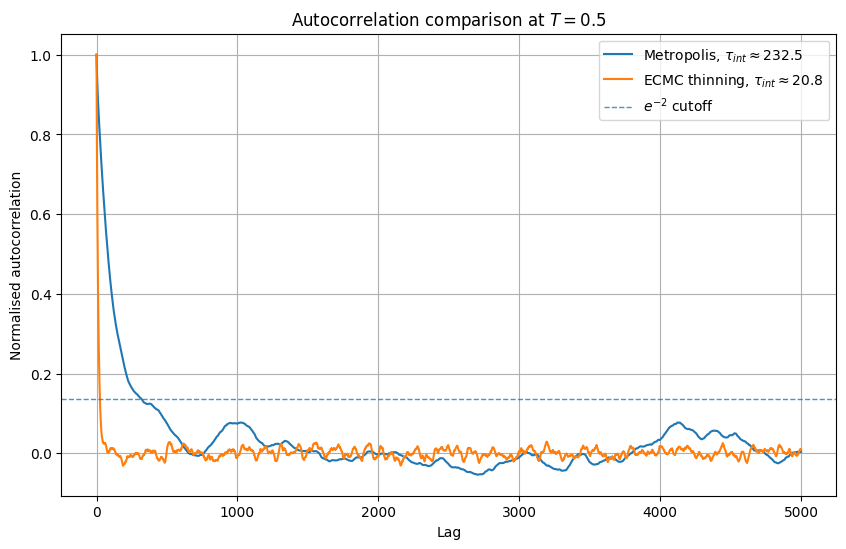

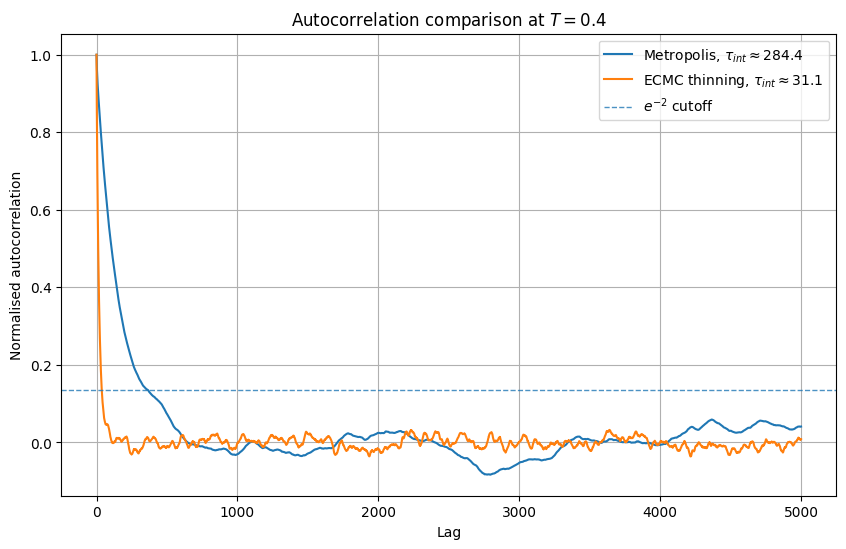

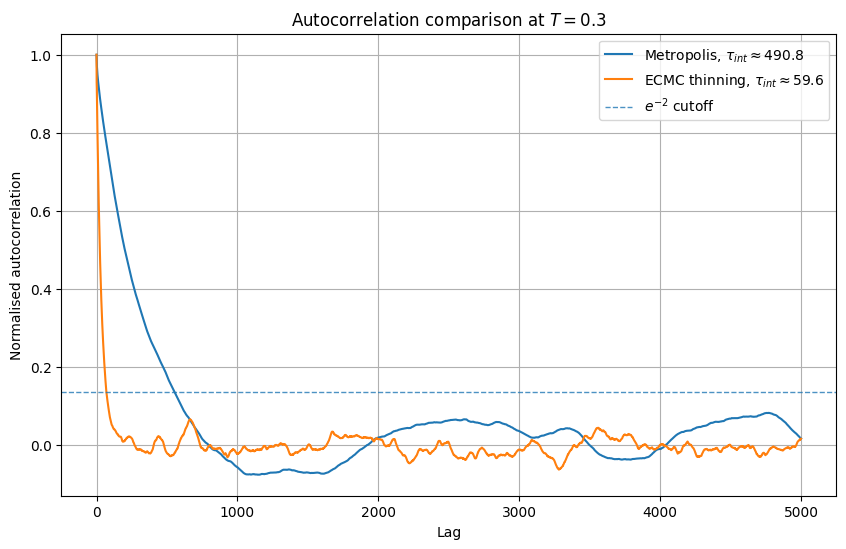

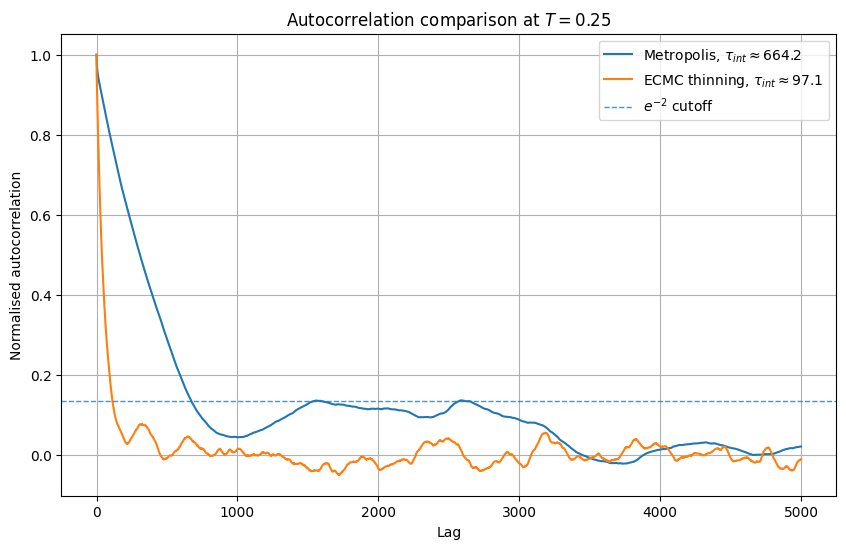

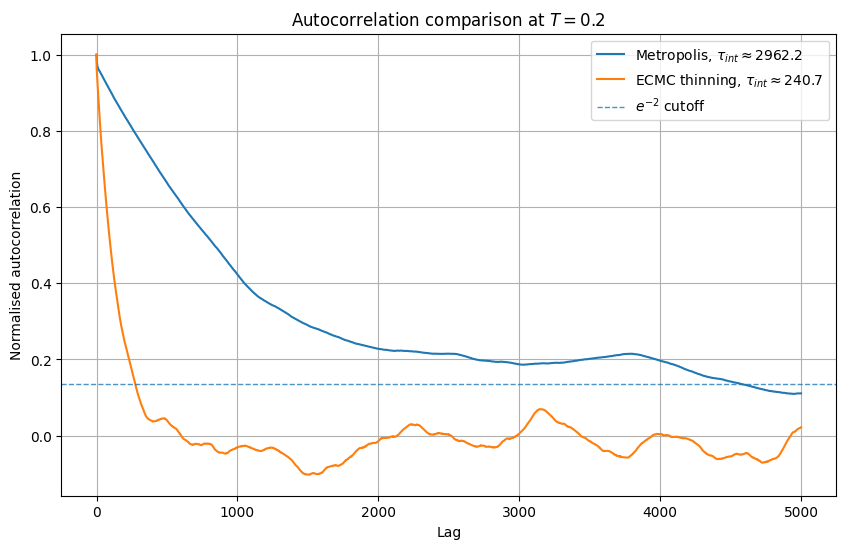

In [39]:
for temp in temperatures:

    result = results[temp]

    lags = np.arange(len(result["rho_metropolis"]))

    plt.figure(figsize=(10, 6))

    plt.plot(
        lags,
        result["rho_metropolis"],
        label=fr"Metropolis, $\tau_{{int}} \approx {result['tau_metropolis']:.1f}$"
    )

    plt.plot(
        lags,
        result["rho_ecmc"],
        label=fr"ECMC thinning, $\tau_{{int}} \approx {result['tau_ecmc']:.1f}$"
    )

    plt.axhline(
        np.exp(-2),
        linestyle="--",
        linewidth=1,
        alpha=0.8,
        label=r"$e^{-2}$ cutoff"
    )

    plt.xlabel("Lag")
    plt.ylabel("Normalised autocorrelation")
    plt.title(fr"Autocorrelation comparison at $T={temp}$")
    plt.grid()
    plt.legend()
    plt.show()

### Tempering Framework

In [40]:
def partition_function_trapezoid(beta, potential_func, x_grid):
    """
    Approximate the partition function using the trapezoidal rule.

    Args:
        beta (float): The inverse temperature.
        potential_func (callable): The potential energy function.
        x_grid (np.ndarray): Grid used for numerical integration.

    Returns:
        float: The approximate partition function.
    """
    unnormalised_density = np.exp(
        -beta * potential_func(x_grid)
    )

    partition_value = np.trapezoid(
        unnormalised_density,
        x_grid
    )

    return partition_value

In [41]:
tempering_temperatures = np.array(temperatures, dtype=float)
tempering_betas = 1.0 / tempering_temperatures

x_grid_tempering = np.linspace(-5, 5, 20_001)

partition_functions = np.array([
    partition_function_trapezoid(
        beta=beta,
        potential_func=double_potential,
        x_grid=x_grid_tempering
    )
    for beta in tempering_betas
])

tempering_log_weights = -np.log(partition_functions)

marginal_check = (
    partition_functions
    * np.exp(tempering_log_weights)
)

In [42]:
weights_df = pd.DataFrame({
    "Temperature": tempering_temperatures,
    "Beta": tempering_betas,
    "Z(beta)": partition_functions,
    "g(beta)": tempering_log_weights,
    "Marginal Check": marginal_check
})

print(weights_df.to_string(index=False))

print(
    "\nAll values finite:",
    np.all(np.isfinite(partition_functions))
)

print(
    "All partition functions positive:",
    np.all(partition_functions > 0)
)

print(
    "All marginal checks equal to 1:",
    np.allclose(marginal_check, 1.0)
)

 Temperature     Beta    Z(beta)   g(beta)  Marginal Check
        1.50 0.666667   6.341758 -1.847156             1.0
        1.20 0.833333   6.908404 -1.932739             1.0
        1.00 1.000000   7.587482 -2.026500             1.0
        0.80 1.250000   8.832934 -2.178487             1.0
        0.70 1.428571   9.911448 -2.293690             1.0
        0.60 1.666667  11.639229 -2.454381             1.0
        0.50 2.000000  14.743640 -2.690812             1.0
        0.40 2.500000  21.453897 -3.065906             1.0
        0.30 3.333333  41.782270 -3.732472             1.0
        0.25 4.000000  73.185824 -4.293002             1.0
        0.20 5.000000 175.058853 -5.165122             1.0

All values finite: True
All partition functions positive: True
All marginal checks equal to 1: True


In [43]:
def propose_temperature_index(current_index, num_temperatures, rng):
    """
    Propose a new temperature index for simulated tempering.

    Args:
        current_index (int): The current temperature index.
        num_temperatures (int): The total number of temperatures.
        rng (numpy.random.Generator): A random number generator.

    Returns:
        int: The proposed temperature index.
    """
    if current_index == 0:
        return 1

    if current_index == num_temperatures - 1:
        return num_temperatures - 2

    return current_index + rng.choice([-1, 1])

In [44]:
def temperature_proposal_probability(current_index, proposed_index, num_temperatures):
    """
    Calculate the probability of proposing a new temperature index for simulated tempering.

    Args:
        current_index (int): The current temperature index.
        proposed_index (int): The proposed temperature index.
        num_temperatures (int): The total number of temperatures.

    Returns:
        float: The probability of proposing the new temperature index.
    """
    if abs(proposed_index - current_index) != 1:
        return 0.0

    if current_index == 0:
        return 1.0

    if current_index == num_temperatures - 1:
        return 1.0

    return 0.5

In [45]:
def simulated_tempering_temperature_step(x_current, current_index, betas, log_weights, potential_func, rng):
    """
    Perform a single temperature step in simulated tempering.

    Args:
        x_current (float): The current position in the state space.
        current_index (int): The current temperature index.
        betas (list): The list of inverse temperatures.
        log_weights (list): The log weights for each temperature.
        potential_func (callable): The potential function.
        rng (numpy.random.Generator): A random number generator.

    Returns:
        tuple: The new temperature index, a boolean indicating if the move was accepted, and the acceptance probability.
    """
    num_temperatures = len(betas)

    proposed_index = propose_temperature_index(
        current_index,
        num_temperatures,
        rng
    )

    q_forward = temperature_proposal_probability(
        current_index,
        proposed_index,
        num_temperatures
    )

    q_reverse = temperature_proposal_probability(
        proposed_index,
        current_index,
        num_temperatures
    )

    beta_current = betas[current_index]
    beta_proposed = betas[proposed_index]

    g_current = log_weights[current_index]
    g_proposed = log_weights[proposed_index]

    energy = potential_func(x_current)

    log_acceptance_ratio = (
        -(beta_proposed - beta_current) * energy
        + (g_proposed - g_current)
        + np.log(q_reverse / q_forward)
    )

    acceptance_probability = np.exp(
        min(0.0, log_acceptance_ratio)
    )

    if rng.random() < acceptance_probability:
        return proposed_index, True, acceptance_probability

    return current_index, False, acceptance_probability

In [46]:
tempering_rng = np.random.default_rng(seed=42)

current_index = 0
x_current = left_minimum

new_index, accepted, acceptance_probability = (
    simulated_tempering_temperature_step(
        x_current=x_current,
        current_index=current_index,
        betas=tempering_betas,
        log_weights=tempering_log_weights,
        potential_func=double_potential,
        rng=tempering_rng
    )
)

print(f"Current temperature: {tempering_temperatures[current_index]}")
print(f"Temperature after step: {tempering_temperatures[new_index]}")
print(f"Acceptance probability: {acceptance_probability:.4f}")
print(f"Accepted: {accepted}")

Current temperature: 1.5
Temperature after step: 1.5
Acceptance probability: 0.5422
Accepted: False


In [47]:
def simulated_tempering_step(x_current, current_index, betas, log_weights, metropolis_proposal_width, potential_func, rng):
    current_temperature = 1.0 / betas[current_index]

    # Update the position at the current temperature.
    x_new, position_accepted = metropolis_step(
        x_current=x_current,
        proposal_width=metropolis_proposal_width,
        temperature=current_temperature,
        potential_func=potential_func,
        rng=rng
    )

    # Attempt to update the temperature at the new position.
    new_index, temperature_accepted, temperature_acceptance_probability = (
        simulated_tempering_temperature_step(
            x_current=x_new,
            current_index=current_index,
            betas=betas,
            log_weights=log_weights,
            potential_func=potential_func,
            rng=rng
        )
    )

    return x_new, new_index, position_accepted, temperature_accepted, temperature_acceptance_probability


In [48]:
test_rng = np.random.default_rng(seed=42)

x_before = left_minimum
index_before = 0

(
    x_after,
    index_after,
    position_accepted,
    temperature_accepted,
    temperature_acceptance_probability
) = simulated_tempering_step(
    x_current=x_before,
    current_index=index_before,
    betas=tempering_betas,
    log_weights=tempering_log_weights,
    metropolis_proposal_width=1.0,
    potential_func=double_potential,
    rng=test_rng
)

print(f"Position before step: {x_before:.4f}")
print(f"Position after step: {x_after:.4f}")
print(f"Position move accepted: {position_accepted}")

print(f"Temperature before step: {tempering_temperatures[index_before]}")
print(f"Temperature after step: {tempering_temperatures[index_after]}")


print(f"Temperature acceptance probability: {temperature_acceptance_probability:.4f}")
print(f"Temperature move accepted: {temperature_accepted}")

Position before step: -1.4142
Position after step: -1.1403
Position move accepted: True
Temperature before step: 1.5
Temperature after step: 1.5
Temperature acceptance probability: 0.5313
Temperature move accepted: False


In [49]:
def run_simulated_tempering(initial_x, initial_index, num_steps, betas, log_weights, metropolis_proposal_width, potential_func, rng):
    """
    Run reversible simulated tempering.

    Args:
        initial_x (float): Initial position.
        initial_index (int): Initial inverse-temperature index.
        num_steps (int): Number of simulated-tempering steps.
        betas (np.ndarray): Available inverse temperatures.
        log_weights (np.ndarray): Precomputed tempering log weights.
        metropolis_proposal_width (float): Width of the position proposal.
        potential_func (callable): Potential energy function.
        rng (numpy.random.Generator): Random number generator.

    Returns:
        dict: Position and temperature trajectories and acceptance rates.
    """
    current_x = initial_x
    current_index = initial_index

    position_trajectory = np.empty(num_steps)
    temperature_index_trajectory = np.empty(
        num_steps,
        dtype=int
    )

    accepted_position_moves = 0
    accepted_temperature_moves = 0

    for step in range(num_steps):

        (
            current_x,
            current_index,
            position_accepted,
            temperature_accepted,
            _
        ) = simulated_tempering_step(
            x_current=current_x,
            current_index=current_index,
            betas=betas,
            log_weights=log_weights,
            metropolis_proposal_width=metropolis_proposal_width,
            potential_func=potential_func,
            rng=rng
        )

        position_trajectory[step] = current_x
        temperature_index_trajectory[step] = current_index

        if position_accepted:
            accepted_position_moves += 1

        if temperature_accepted:
            accepted_temperature_moves += 1

    position_acceptance_rate = (
        accepted_position_moves / num_steps
    )

    temperature_acceptance_rate = (
        accepted_temperature_moves / num_steps
    )

    return {
        "position_trajectory": position_trajectory,
        "temperature_index_trajectory": temperature_index_trajectory,
        "position_acceptance_rate": position_acceptance_rate,
        "temperature_acceptance_rate": temperature_acceptance_rate
    }

In [50]:
tempering_rng = np.random.default_rng(seed=42)

num_burn_in_steps_tempering = 1_000
num_tempering_samples = 10**5
num_tempering_steps = num_burn_in_steps_tempering + num_tempering_samples

initial_temperature_index = len(tempering_betas) - 1

tempering_results = run_simulated_tempering(
    left_minimum, initial_temperature_index, num_tempering_steps, tempering_betas,
    tempering_log_weights, 1.0, double_potential, tempering_rng
)

tempering_position_samples = tempering_results["position_trajectory"][num_burn_in_steps_tempering:]
tempering_temperature_indices = tempering_results["temperature_index_trajectory"][num_burn_in_steps_tempering:]
tempering_temperature_samples = tempering_temperatures[tempering_temperature_indices]

print(f"Position acceptance rate: {100 * tempering_results['position_acceptance_rate']:.2f}%")
print(f"Temperature acceptance rate: {100 * tempering_results['temperature_acceptance_rate']:.2f}%")
print(f"Number of temperatures visited: {len(np.unique(tempering_temperature_indices))}")
print("Temperatures visited:", np.unique(tempering_temperature_samples))

Position acceptance rate: 77.69%
Temperature acceptance rate: 87.47%
Number of temperatures visited: 11
Temperatures visited: [0.2  0.25 0.3  0.4  0.5  0.6  0.7  0.8  1.   1.2  1.5 ]
